<a href="https://colab.research.google.com/github/eacharan21/bmi-prediction-ml/blob/main/Analysis_on_Nutrition_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Library

In [ ]:
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn import metrics
from sklearn.model_selection import train_test_split
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
from xgboost import XGBRegressor
import tensorflow as tf
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
import torch
import torchvision
import torch.nn.functional as F
from keras.models import Sequential
from keras.layers import Dense, Conv1D, Flatten, MaxPooling1D, SimpleRNN
import math
from sklearn import preprocessing

## Data

In [ ]:
data=pd.read_excel('/content/Nutrition dataset.xlsx')
data

,S.No,Age,Class,M/F,Weight,Height,Hgt Modified,BMI,V/NV,"Food quantity 1,2,3","Skip BF Yes/No, 1,2","Skip lun Yes/No, 1.2","skip Dine Yes/No, 1,2",Like fruits
0,1,10-11,5,F,35.0,1.48,148.0,15.98,NV,3.0,"YES,1",NO,"NO,1",Y
1,2,10-11,6,F,26.0,128.00,128.0,15.95,V,2.0,No,No,No,Y
2,3,11-12,6,M,25.0,130.20,130.2,14.747488,V,3.0,No,No,No,Y
3,4,11-12,6,M,45.0,139.60,139.6,23.090943,NV,2.0,"Yes,1",Yes,No,Y
4,5,11-12,6,M,40.0,143.00,143.0,19.560859,NV,3.0,No,No,No,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
666,667,11-12,6,M,41.0,134.00,134.0,22.833593,NV,3.0,No,No,No,Y
667,668,11-12,6,M,49.0,142.90,142.9,23.9956,V,3.0,"Yes,2",No,No,Y
668,669,11-12,6,M,33.5,127.10,127.1,20.737371,NV,2.0,No,No,No,Y
669,670,11-12,6,M,22.5,129.00,129.0,13.520822,NV,3.0,No,No,No,Y


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 671 entries, 0 to 670
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   S.No                   671 non-null    int64  
 1   Age                    671 non-null    object 
 2   Class                  671 non-null    object 
 3   M/F                    671 non-null    object 
 4   Weight                 664 non-null    float64
 5   Height                 663 non-null    float64
 6   Hgt Modified           663 non-null    float64
 7   BMI                    663 non-null    object 
 8   V/NV                   645 non-null    object 
 9   Food quantity 1,2,3    649 non-null    float64
 10  Skip BF Yes/No, 1,2    653 non-null    object 
 11  Skip lun Yes/No, 1.2   654 non-null    object 
 12  skip Dine Yes/No, 1,2  647 non-null    object 
 13  Like fruits            670 non-null    object 
dtypes: float64(4), int64(1), object(9)
memory usage: 73.5+ KB


In [ ]:
data.shape

(671, 14)

## Data preprocessing

In [ ]:
data.isnull().sum()

S.No                      0
Age                       0
Class                     0
M/F                       0
Weight                    7
Height                    8
Hgt Modified              8
BMI                       8
V/NV                     26
Food quantity 1,2,3      22
Skip BF Yes/No, 1,2      18
Skip lun Yes/No, 1.2     17
skip Dine Yes/No, 1,2    24
Like fruits               1
dtype: int64

In [ ]:
data.rename(columns = {'Skip BF Yes/No, 1,2':'Skip_BF'}, inplace = True)
data.rename(columns = {'Skip lun Yes/No, 1.2':'Skip_lunch'}, inplace = True)
data.rename(columns = {'skip Dine Yes/No, 1,2':'Skip_dinner'}, inplace = True)
data.rename(columns = {'Food quantity 1,2,3':'Food_quantity'}, inplace = True)
data.rename(columns = {'Like fruits':'Like_fruits'}, inplace = True)
data.rename(columns = {'Hgt Modified ':'Hgt_Modified'}, inplace = True)
data.rename(columns = {'V/NV':'veg_nonveg'}, inplace = True)
data.rename(columns = {'M/F':'gender'}, inplace = True)

In [ ]:
data['gender'].unique()

array(['F', 'M', ' F', 'M ', 'm'], dtype=object)

In [ ]:
data['veg_nonveg'].unique()

array(['NV', 'V', nan, 'v', 'V ', 'nv'], dtype=object)

In [ ]:
data['veg_nonveg'] = data.veg_nonveg.map({'NV':0, 'nv':0, 'v':1, 'V ':1, 'V':1})
data['gender'] = data.gender.map({'F':0, ' F':0, 'M':1, 'M ':1, 'm':1})
data['Like_fruits'] = data.Like_fruits.map({'N':0, 'n':0, 'Y':1, 'y':1, 'Y ':1})

In [ ]:
data['Skip_BF'].unique()

array(['YES,1', 'No', 'Yes,1', 'Yes', 'Yes,2', nan, 'NO', 'YES', 'NO,1',
       'YES,2', 'No ', 'Y,1', 'Y,2', 'no', 2, 'yes,1', 1, 'NO,2', 'yes,2',
       'yes', 'Y'], dtype=object)

In [ ]:
data['Skip_BF']= data.Skip_BF.map({'YES,1':1, 'No':0, 'Yes,1':1, 'Yes':1, 'Yes,2':2, 'NO':0, 'YES':1, 'NO,1':0,
       'YES,2':2, 'No ':0, 'Y,1':1, 'Y,2':2, 'no':0 , 'yes,1':1, 'NO,2':0, 'yes,2':2,
       'yes':1, 'Y':1})

In [ ]:
data['Skip_BF'].unique()

array([ 1.,  0.,  2., nan])

In [ ]:
data['Skip_lunch'].unique()

array(['NO', 'No ', 'Yes', 'Yes,1', 'Junk', 'YES,1', 'NO,2', 'YES',
       'NO,1', nan, 'YES,2', 'Yes,2', 'no', 'Y,2', 'Y,1', 'yes,1',
       'yes,2', 'no,2', 'Y'], dtype=object)

In [ ]:
data['Skip_lunch'] = data.Skip_lunch.map({'NO':0, 'No ':0, 'Yes':1, 'Yes,1':1, 'Junk':1, 'YES,1':1, 'NO,2':0, 'YES':1,
       'NO,1':0, 'YES,2':2, 'Yes,2':2, 'no':0, 'Y,2':2, 'Y,1':1, 'yes,1':1,
       'yes,2':2, 'no,2':0, 'Y':1})

In [ ]:
data['Skip_lunch'].unique()

array([ 0.,  1., nan,  2.])

In [ ]:
data['Skip_dinner'].unique()

array(['NO,1', 'No', 'Yes,2', 'Yes,1', nan, 'YES,1', 'NO,2', 'NO', 'YES',
       'YES,2', 'Yes', 'Yes1', 'Y,1', 'no', 'Y,2', 'Y,3', 2, 'yes,1',
       'yes,2', 'yes', 'YES '], dtype=object)

In [ ]:
data['Skip_dinner'] = data.Skip_dinner.map({'NO,1':0, 'No':0, 'Yes,2':2, 'Yes,1':1, 'YES,1':1, 'NO,2':0, 'NO':0, 'YES':1,
       'YES,2':2, 'Yes':1, 'Yes1':1, 'Y,1':1, 'no':0, 'Y,2':2, 'Y,3':2, 'yes,1':1,
       'yes,2':2, 'yes':1, 'YES ':1})

In [ ]:
data['Skip_dinner'].unique()

array([ 0.,  2.,  1., nan])

In [ ]:
data['Class'].unique()

array([5, 6, 7, 8, 9, 10, 'Inter 1st', 'B.Sc', 'Inter 2nd', 'B.SC'],
      dtype=object)

In [ ]:
data['Age']=data['Age'].replace('11 -12','11-12')
data['Age']=data['Age'].replace(11,'11-12')
data['Class']=data['Class'].replace('B.SC','B.Sc')

In [ ]:
data

,S.No,Age,Class,gender,Weight,Height,Hgt_Modified,BMI,veg_nonveg,Food_quantity,Skip_BF,Skip_lunch,Skip_dinner,Like_fruits
0,1,10-11,5,0,35.0,1.48,148.0,15.98,0.0,3.0,1.0,0.0,0.0,1.0
1,2,10-11,6,0,26.0,128.00,128.0,15.95,1.0,2.0,0.0,0.0,0.0,1.0
2,3,11-12,6,1,25.0,130.20,130.2,14.747488,1.0,3.0,0.0,0.0,0.0,1.0
3,4,11-12,6,1,45.0,139.60,139.6,23.090943,0.0,2.0,1.0,1.0,0.0,1.0
4,5,11-12,6,1,40.0,143.00,143.0,19.560859,0.0,3.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
666,667,11-12,6,1,41.0,134.00,134.0,22.833593,0.0,3.0,0.0,0.0,0.0,1.0
667,668,11-12,6,1,49.0,142.90,142.9,23.9956,1.0,3.0,2.0,0.0,0.0,1.0
668,669,11-12,6,1,33.5,127.10,127.1,20.737371,0.0,2.0,0.0,0.0,0.0,1.0
669,670,11-12,6,1,22.5,129.00,129.0,13.520822,0.0,3.0,0.0,0.0,0.0,1.0


In [ ]:
data['BMI'] = pd.to_numeric(data['BMI'], errors='coerce')

In [ ]:
data.isnull().sum()

S.No              0
Age               0
Class             0
gender            0
Weight            7
Height            8
Hgt_Modified      8
BMI               9
veg_nonveg       26
Food_quantity    22
Skip_BF          22
Skip_lunch       17
Skip_dinner      26
Like_fruits       1
dtype: int64

In [ ]:
data = data.apply(lambda x: x.fillna(x.mode()[0]))

In [ ]:
data

,S.No,Age,Class,gender,Weight,Height,Hgt_Modified,BMI,veg_nonveg,Food_quantity,Skip_BF,Skip_lunch,Skip_dinner,Like_fruits
0,1,10-11,5,0,35.0,1.48,148.0,15.980000,0.0,3.0,1.0,0.0,0.0,1.0
1,2,10-11,6,0,26.0,128.00,128.0,15.950000,1.0,2.0,0.0,0.0,0.0,1.0
2,3,11-12,6,1,25.0,130.20,130.2,14.747488,1.0,3.0,0.0,0.0,0.0,1.0
3,4,11-12,6,1,45.0,139.60,139.6,23.090943,0.0,2.0,1.0,1.0,0.0,1.0
4,5,11-12,6,1,40.0,143.00,143.0,19.560859,0.0,3.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
666,667,11-12,6,1,41.0,134.00,134.0,22.833593,0.0,3.0,0.0,0.0,0.0,1.0
667,668,11-12,6,1,49.0,142.90,142.9,23.995600,1.0,3.0,2.0,0.0,0.0,1.0
668,669,11-12,6,1,33.5,127.10,127.1,20.737371,0.0,2.0,0.0,0.0,0.0,1.0
669,670,11-12,6,1,22.5,129.00,129.0,13.520822,0.0,3.0,0.0,0.0,0.0,1.0


In [ ]:
data.isnull().sum()

S.No             0
Age              0
Class            0
gender           0
Weight           0
Height           0
Hgt_Modified     0
BMI              0
veg_nonveg       0
Food_quantity    0
Skip_BF          0
Skip_lunch       0
Skip_dinner      0
Like_fruits      0
dtype: int64

In [ ]:
print(data.info)

<bound method DataFrame.info of      S.No    Age Class  gender  Weight  Height  Hgt_Modified        BMI  \
0       1  10-11     5       0    35.0    1.48         148.0  15.980000   
1       2  10-11     6       0    26.0  128.00         128.0  15.950000   
2       3  11-12     6       1    25.0  130.20         130.2  14.747488   
3       4  11-12     6       1    45.0  139.60         139.6  23.090943   
4       5  11-12     6       1    40.0  143.00         143.0  19.560859   
..    ...    ...   ...     ...     ...     ...           ...        ...   
666   667  11-12     6       1    41.0  134.00         134.0  22.833593   
667   668  11-12     6       1    49.0  142.90         142.9  23.995600   
668   669  11-12     6       1    33.5  127.10         127.1  20.737371   
669   670  11-12     6       1    22.5  129.00         129.0  13.520822   
670   671  11-12     6       1    25.5  132.40         132.4  14.546691   

     veg_nonveg  Food_quantity  Skip_BF  Skip_lunch  Skip_dinner  L

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 671 entries, 0 to 670
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   S.No           671 non-null    int64  
 1   Age            671 non-null    object 
 2   Class          671 non-null    object 
 3   gender         671 non-null    int64  
 4   Weight         671 non-null    float64
 5   Height         671 non-null    float64
 6   Hgt_Modified   671 non-null    float64
 7   BMI            671 non-null    float64
 8   veg_nonveg     671 non-null    float64
 9   Food_quantity  671 non-null    float64
 10  Skip_BF        671 non-null    float64
 11  Skip_lunch     671 non-null    float64
 12  Skip_dinner    671 non-null    float64
 13  Like_fruits    671 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 73.5+ KB


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 671 entries, 0 to 670
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   S.No           671 non-null    int64  
 1   Age            671 non-null    object 
 2   Class          671 non-null    object 
 3   gender         671 non-null    int64  
 4   Weight         671 non-null    float64
 5   Height         671 non-null    float64
 6   Hgt_Modified   671 non-null    float64
 7   BMI            671 non-null    float64
 8   veg_nonveg     671 non-null    float64
 9   Food_quantity  671 non-null    float64
 10  Skip_BF        671 non-null    float64
 11  Skip_lunch     671 non-null    float64
 12  Skip_dinner    671 non-null    float64
 13  Like_fruits    671 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 73.5+ KB


In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

In [ ]:
#data.to_csv('/content/drive/MyDrive/Nutrition_Data.csv', index=False)

In [ ]:
#from google.colab import files
#files.download('/content/drive/MyDrive/Nutrition_Data.csv')

## EDA

In [ ]:
data['Class'].unique()

array([5, 6, 7, 8, 9, 10, 'Inter 1st', 'B.Sc', 'Inter 2nd'], dtype=object)

/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='Weight'>

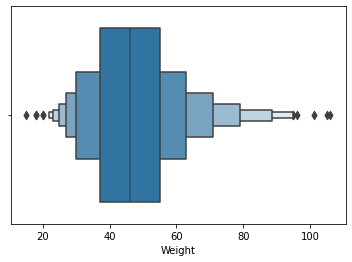

In [ ]:
sns.boxenplot(data['Weight'])

/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='Hgt_Modified'>

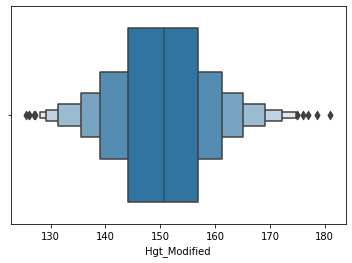

In [ ]:
sns.boxenplot(data['Hgt_Modified'])

/usr/local/lib/python3.8/dist-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='BMI'>

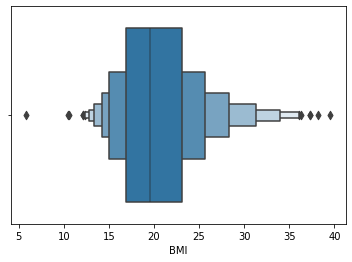

In [ ]:
sns.boxenplot(data['BMI'])

<AxesSubplot:xlabel='Age', ylabel='BMI'>

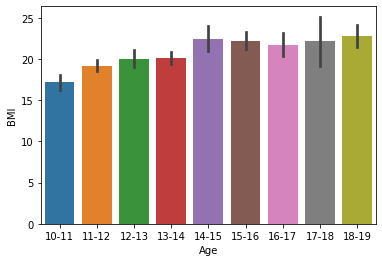

In [ ]:
sns.barplot(x="Age",y="BMI",data=data)

<AxesSubplot:xlabel='Class', ylabel='BMI'>

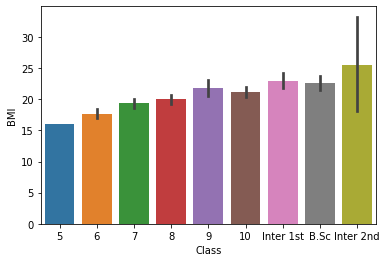

In [ ]:
sns.barplot(x="Class",y="BMI",data=data)

<AxesSubplot:xlabel='gender', ylabel='BMI'>

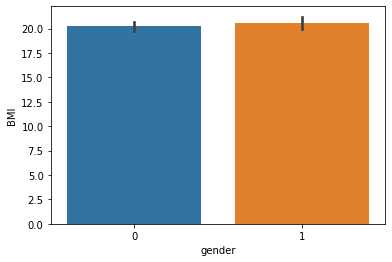

In [ ]:
sns.barplot(x="gender",y="BMI",data=data)

In [ ]:
data

,S.No,Age,Class,gender,Weight,Height,Hgt_Modified,BMI,veg_nonveg,Food_quantity,Skip_BF,Skip_lunch,Skip_dinner,Like_fruits
0,1,10-11,5,0,35.0,1.48,148.0,15.980000,0.0,3.0,1.0,0.0,0.0,1.0
1,2,10-11,6,0,26.0,128.00,128.0,15.950000,1.0,2.0,0.0,0.0,0.0,1.0
2,3,11-12,6,1,25.0,130.20,130.2,14.747488,1.0,3.0,0.0,0.0,0.0,1.0
3,4,11-12,6,1,45.0,139.60,139.6,23.090943,0.0,2.0,1.0,1.0,0.0,1.0
4,5,11-12,6,1,40.0,143.00,143.0,19.560859,0.0,3.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
666,667,11-12,6,1,41.0,134.00,134.0,22.833593,0.0,3.0,0.0,0.0,0.0,1.0
667,668,11-12,6,1,49.0,142.90,142.9,23.995600,1.0,3.0,2.0,0.0,0.0,1.0
668,669,11-12,6,1,33.5,127.10,127.1,20.737371,0.0,2.0,0.0,0.0,0.0,1.0
669,670,11-12,6,1,22.5,129.00,129.0,13.520822,0.0,3.0,0.0,0.0,0.0,1.0


<ipython-input-204-544c1e7506e1>:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  heatmap = sns.heatmap(data.corr(), annot=True, cmap="coolwarm", linewidths=.5)


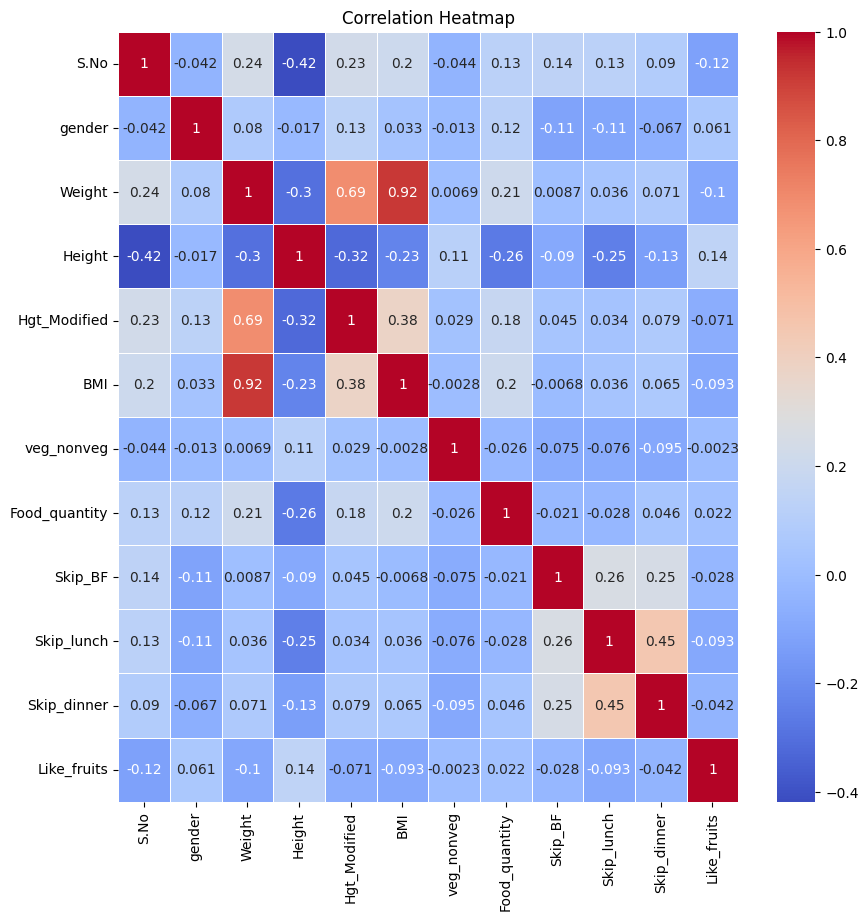

In [ ]:
plt.figure(figsize=(10, 10))
heatmap = sns.heatmap(data.corr(), annot=True, cmap="coolwarm", linewidths=.5)
plt.title("Correlation Heatmap")

# Show the plot
plt.show()

#ML Algorithms

## Training & Testing Data

In [ ]:
x = data.drop(['S.No','Age','Class','Height','BMI'],axis=1)
y = data['BMI']

In [ ]:
x

,gender,Weight,Hgt_Modified,veg_nonveg,Food_quantity,Skip_BF,Skip_lunch,Skip_dinner,Like_fruits
0,0,35.0,148.0,0.0,3.0,1.0,0.0,0.0,1.0
1,0,26.0,128.0,1.0,2.0,0.0,0.0,0.0,1.0
2,1,25.0,130.2,1.0,3.0,0.0,0.0,0.0,1.0
3,1,45.0,139.6,0.0,2.0,1.0,1.0,0.0,1.0
4,1,40.0,143.0,0.0,3.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...
666,1,41.0,134.0,0.0,3.0,0.0,0.0,0.0,1.0
667,1,49.0,142.9,1.0,3.0,2.0,0.0,0.0,1.0
668,1,33.5,127.1,0.0,2.0,0.0,0.0,0.0,1.0
669,1,22.5,129.0,0.0,3.0,0.0,0.0,0.0,1.0


In [ ]:
y

0      15.980000
1      15.950000
2      14.747488
3      23.090943
4      19.560859
         ...    
666    22.833593
667    23.995600
668    20.737371
669    13.520822
670    14.546691
Name: BMI, Length: 671, dtype: float64

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state = 42)

## Linear regression

#### Training dataset

In [ ]:
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [ ]:
x_pred = lr.predict(x_train)
x_pred

array([21.12945851, 17.41734885, 17.02417123, 16.37936598, 17.69146756,
       16.10772423, 19.32321949, 14.22437351, 14.54650776, 24.73397851,
       20.75844857, 24.85481489, 18.27850366, 15.93244755, 16.78656617,
       15.44060431, 15.6249547 , 22.78677661, 15.62081076, 21.23118417,
       16.78745092, 25.66807494, 23.95008545, 26.35262002, 18.63039319,
       16.13008338, 16.37411793, 21.8213275 , 20.91379556, 22.8606968 ,
       19.66929758, 23.15769081, 21.72708094, 17.88663643, 19.69887803,
       22.41638726, 18.58499045, 18.07898613, 21.09382261, 20.27844319,
       16.49477848, 31.51020367, 23.64294307, 18.90205869, 23.39267941,
       16.03098662, 20.78639709, 21.93270995, 15.76212479, 16.02010687,
       21.72574896, 18.00789394, 15.16423761, 26.635392  , 17.58060978,
       22.8767737 , 18.78971096, 22.59334088, 16.0056019 , 19.02766316,
       36.2994263 , 29.2341589 , 15.71216538, 19.99919682, 19.00073301,
       14.99361765, 21.87636031, 18.4325659 , 15.59569953, 19.78

In [ ]:
r2_score(y_train,x_pred)

0.9700865882000952

In [ ]:
metrics.mean_absolute_error(y_train,x_pred)

0.5075669479842386

In [ ]:
mean_squared_error(y_train,x_pred)

0.6747256973496744

#### Testing dataset

In [ ]:
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [ ]:
y_pred = lr.predict(x_test)
y_pred

array([22.71656412, 17.28729405, 23.50549205, 20.6060627 , 16.7362101 ,
       18.83031452, 32.21515795, 16.8758247 , 21.05988598, 15.41242097,
       20.80764214, 16.35293824, 19.67040624, 15.25008877, 14.23870396,
       21.36368127, 35.08600192, 23.52488864, 18.67842424, 26.06165361,
       15.97855908, 17.7259842 , 21.63645601, 24.88999588, 22.94588917,
       14.1525643 , 12.8639211 , 22.69243342, 17.83044562, 16.38018803,
       24.34577261, 19.66929758, 24.08810621, 13.65556698, 14.21319774,
       15.26588999, 24.39795248, 21.36291542, 15.22605732, 16.15575529,
       18.73772994, 18.45692336, 14.46098444, 20.95777177, 20.05008338,
       14.26346809, 16.95161371, 22.1797308 , 13.81604726, 19.01324679,
       26.57396897, 18.23859199, 26.95775698, 24.69245578, 15.33969574,
       20.87661522, 13.32150113, 16.08130519, 15.30037418, 30.19683011,
       30.33513693, 17.53353531, 16.24260256, 14.98151342, 15.62257347,
       22.02153602, 22.5624583 , 19.66881893, 23.85202302, 13.73

In [ ]:
r2_score(y_test,y_pred)

0.9612992477981762

In [ ]:
metrics.mean_absolute_error(y_test,y_pred)

0.6082275801314821

In [ ]:
mean_squared_error(y_test,y_pred)

1.046817013083921

## Decision tree

#### Training dataset

In [ ]:
dt=DecisionTreeRegressor()
dt.fit(x_train,y_train)

DecisionTreeRegressor()

In [ ]:
x_pred = dt.predict(x_train)
x_pred

array([21.33      , 17.5663492 , 17.31235023, 16.04471818, 18.01      ,
       15.73      , 19.5046224 , 13.86951939, 14.17082935, 25.32      ,
       20.88282966, 25.08      , 18.5       , 15.89279357, 17.0066073 ,
       16.45600644, 15.52227904, 23.53      , 16.09      , 21.21831719,
       16.5       , 26.22      , 24.77365884, 25.81498476, 18.84410274,
       15.75869498, 15.38      , 22.541561  , 21.09      , 25.        ,
       18.14      , 24.18963411, 22.55176871, 18.14      , 18.14      ,
       23.46      , 18.80896391, 18.04881825, 21.42      , 20.06920415,
       15.2       , 30.743977  , 23.92      , 19.11      , 24.09040989,
       20.6       , 20.87623707, 22.42603962, 16.10451184, 15.70395512,
       22.14      , 18.229     , 15.06      , 26.03      , 17.39      ,
       23.07      , 19.066     , 21.3       , 15.98      , 19.11372667,
       33.95      , 30.41854536, 15.7017634 , 19.8       , 19.23      ,
       14.38830436, 22.37      , 18.7       , 15.54327637, 18.14

In [ ]:
r2_score(y_train,x_pred)

0.9999901013126139

In [ ]:
metrics.mean_absolute_error(y_train,x_pred)

0.0009765275280481723

In [ ]:
mean_squared_error(y_train,x_pred)

0.0002232743892314165

#### Testing dataset

In [ ]:
dt=DecisionTreeRegressor()
dt.fit(x_train,y_train)

DecisionTreeRegressor()

In [ ]:
y_pred = dt.predict(x_test)
y_pred

array([22.67573696, 17.26420745, 23.41      , 20.43734905, 16.88019391,
       18.14      , 30.70040788, 17.26      , 21.77      , 14.8780004 ,
       21.21      , 15.34      , 20.01517673, 15.15      , 14.17082935,
       21.42      , 39.55      , 24.12      , 18.9       , 25.55482243,
       16.39436938, 17.13934422, 21.94      , 24.566     , 22.51824274,
       12.57482018, 12.16      , 22.49      , 18.53483202, 16.81      ,
       24.35591021, 18.14      , 25.26985372, 13.46      , 12.73      ,
       15.75869498, 25.30363219, 20.43734905, 14.75      , 14.20292373,
       18.84515944, 18.75      , 14.21      , 21.96      , 20.44      ,
       15.11      , 17.26      , 23.09094342, 13.46      , 18.2388183 ,
       25.91068435, 17.04      , 18.2       , 25.30363219, 13.71742112,
       20.59362316, 12.16      , 16.33169676, 13.98      , 30.743977  ,
       31.70008459, 18.04881825, 15.33      , 14.11      , 15.31      ,
       23.26866949, 23.07      , 19.55      , 24.64      , 13.4 

In [ ]:
r2_score(y_test,y_pred)

0.9186759154348298

In [ ]:
metrics.mean_absolute_error(y_test,y_pred)

0.7918393671818728

In [ ]:
mean_squared_error(y_test,y_pred)

2.199735934132147

## Random forest

#### Training dataset

In [ ]:
rf = RandomForestRegressor(n_estimators = 20, random_state = 42)
rf.fit(x_train,y_train)

RandomForestRegressor(n_estimators=20, random_state=42)

In [ ]:
x_pred = rf.predict(x_train)
x_pred

array([21.36058522, 17.59052175, 17.27878319, 16.15844425, 18.0497843 ,
       16.93753468, 19.56953637, 13.92171163, 14.2054813 , 25.33819354,
       20.91405352, 25.37689677, 18.44692885, 15.88354367, 16.96374842,
       17.10974123, 15.57363952, 23.00215539, 16.03872324, 21.19819818,
       16.66794656, 26.34822494, 24.8814379 , 25.85109199, 18.81787806,
       15.88832548, 15.68766794, 22.54942927, 20.92926052, 23.77479103,
       18.55463206, 23.68432658, 22.55757267, 18.21128217, 18.38187988,
       23.5738178 , 18.7971213 , 18.17771755, 21.43295801, 19.90776715,
       15.735     , 30.81221511, 23.95414811, 19.19793983, 24.15557304,
       18.59164619, 20.87506451, 22.18040351, 16.22558105, 15.71741519,
       21.96455884, 18.32776468, 15.14360052, 25.991     , 17.24377112,
       23.05256573, 19.12869696, 23.06199079, 15.96255871, 19.05069561,
       34.95622912, 29.55086857, 15.74107991, 19.69209176, 19.19140746,
       14.26960793, 22.38364906, 18.7224    , 15.57445728, 18.31

In [ ]:
r2_score(y_train,x_pred)

0.9942928302842925

In [ ]:
metrics.mean_absolute_error(y_train,x_pred)

0.19086975997314837

In [ ]:
mean_squared_error(y_train,x_pred)

0.12853397508625364

#### Testing dataset

In [ ]:
rf = RandomForestRegressor(n_estimators = 20, random_state = 42)
rf.fit(x_train,y_train)

RandomForestRegressor(n_estimators=20, random_state=42)

In [ ]:
y_pred = rf.predict(x_test)
y_pred

array([22.19686016, 17.21888993, 23.02021898, 20.78092722, 16.90421593,
       18.77817119, 32.75346094, 16.91950573, 21.26839389, 14.73324709,
       21.13176028, 15.77545679, 19.30124876, 15.45360008, 14.14409013,
       21.52931956, 36.68025586, 23.81824811, 18.44221607, 24.36835537,
       15.46098691, 17.43949781, 21.79714406, 24.96013088, 23.12571676,
       12.92186276, 12.75329162, 22.79498952, 18.72852408, 16.7538568 ,
       25.50934187, 18.55463206, 24.3440337 , 13.9025    , 12.90554593,
       15.7284991 , 24.9614602 , 20.66799458, 14.49135918, 15.78696269,
       18.78595753, 18.88561322, 14.23771804, 21.73949883, 19.92107128,
       14.26369232, 17.46511637, 22.99326066, 13.72616587, 18.94651505,
       25.91259141, 18.85437226, 23.17236161, 25.16956932, 13.97677392,
       20.9727831 , 13.03716441, 16.61344307, 14.20438855, 29.31500827,
       30.43661841, 17.68087248, 14.0848719 , 14.89682652, 15.54156847,
       21.50657087, 22.88400257, 19.55812478, 23.78555158, 13.12

In [ ]:
r2_score(y_test,y_pred)

0.9535407752720743

In [ ]:
metrics.mean_absolute_error(y_test,y_pred)

0.556647979449353

In [ ]:
mean_squared_error(y_test,y_pred)

1.256676009971452

## Bagging

#### Training dataset

In [ ]:
bag_model = BaggingRegressor(
base_estimator=BaggingRegressor(),
n_estimators=20,
max_samples=0.8,
bootstrap=True,
oob_score=True,
random_state=42
)

In [ ]:
bag=bag_model.fit(x_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


In [ ]:
x_pred = bag.predict(x_train)
x_pred

array([21.44748217, 17.60520061, 17.35375196, 15.87407995, 18.01946101,
       15.74448923, 19.7674504 , 14.09459243, 14.46881985, 25.28872848,
       21.01889574, 25.30099552, 18.38198873, 15.81104164, 16.95268623,
       17.4835007 , 15.62055502, 23.04219891, 16.37968445, 21.24806597,
       16.35009041, 26.00814347, 24.94074222, 25.99641272, 19.12325509,
       15.76870242, 15.17727587, 21.8590912 , 21.19938201, 23.53684324,
       18.931448  , 23.1541163 , 22.54269192, 18.16038832, 18.89457485,
       22.99493582, 18.70961869, 18.32481443, 21.4265517 , 20.11594831,
       15.88570289, 30.60614395, 23.71182907, 19.13640563, 23.85648807,
       17.48139612, 20.98499909, 22.13879401, 16.45892537, 15.62435449,
       21.99285632, 18.10727683, 15.23961722, 26.08350552, 17.21386412,
       22.74453525, 19.31203481, 24.69571101, 15.85967095, 19.09025225,
       34.39347005, 28.59874116, 15.6628105 , 19.97661925, 19.26098069,
       14.52627716, 22.27537022, 18.92815347, 15.6975144 , 18.60

In [ ]:
r2_score(y_train,x_pred)

0.982214751349415

In [ ]:
metrics.mean_absolute_error(y_train,x_pred)

0.350699572360078

In [ ]:
mean_squared_error(y_train,x_pred)

0.40116334367253476

#### Testing dataset

In [ ]:
bag_model = BaggingRegressor(
base_estimator=BaggingRegressor(),
n_estimators=20,
max_samples=0.8,
bootstrap=True,
oob_score=True,
random_state=42
)

In [ ]:
bag=bag_model.fit(x_train, y_train)

/usr/local/lib/python3.8/dist-packages/sklearn/ensemble/_base.py:166: FutureWarning: `base_estimator` was renamed to `estimator` in version 1.2 and will be removed in 1.4.
  warnings.warn(


In [ ]:
y_pred = bag.predict(x_test)
y_pred

array([22.39059241, 17.32900793, 23.36126662, 20.61417176, 17.1055523 ,
       18.57996379, 31.86990403, 17.47196043, 21.27377871, 14.85340122,
       21.05922863, 16.20062394, 19.21984904, 15.34950445, 14.48682138,
       21.67291151, 34.24744247, 23.58711931, 18.59177698, 24.80025404,
       15.31288904, 17.47147029, 21.73197028, 24.36735449, 23.00195875,
       13.3885301 , 13.11560977, 22.79871289, 19.04982684, 16.79974884,
       25.33325313, 18.931448  , 24.02058733, 14.034555  , 13.11575794,
       15.55344519, 25.01114963, 20.8324547 , 14.58809413, 15.84520955,
       18.68737594, 18.68071219, 14.31907052, 21.54221937, 19.83309192,
       14.19841836, 17.69440622, 22.44121918, 14.15239077, 18.76199999,
       26.24108568, 18.99949038, 23.98154446, 25.07368868, 13.85571152,
       21.08089702, 13.21602718, 16.84002658, 14.64131804, 29.5474264 ,
       30.20435938, 17.68340966, 14.11049181, 15.21692146, 15.60252907,
       21.28240246, 22.60447619, 19.52402799, 23.74745133, 13.26

In [ ]:
r2_score(y_test,y_pred)

0.9529511304662249

In [ ]:
metrics.mean_absolute_error(y_test,y_pred)

0.5744717161546947

In [ ]:
mean_squared_error(y_test,y_pred)

1.2726253179130844

## Boosting

#### AdaBoosting

###### Training dataset

In [ ]:
#Ada Boosting
adaclf = AdaBoostRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    random_state=42)
adaclf.fit(x_train, y_train)
x_pred = adaclf.predict(x_train)

In [ ]:
r2_score(y_train,x_pred)

0.9194240787979046

In [ ]:
metrics.mean_absolute_error(y_train,x_pred)

1.0446342772039119

In [ ]:
mean_squared_error(y_train,x_pred)

1.817467194526077

###### Testing dataset

In [ ]:
#Ada Boosting
adaclf = AdaBoostRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    random_state=42)
adaclf.fit(x_train, y_train)
y_pred = adaclf.predict(x_test)

In [ ]:
r2_score(y_test,y_pred)

0.8875662096052224

In [ ]:
metrics.mean_absolute_error(y_test,y_pred)

1.268389474897642

In [ ]:
mean_squared_error(y_test,y_pred)

3.0412226619517266

####GradientBoosting

####### Training dataset

In [ ]:
#GradientBoosting
GradientBoostingRegressor,
gb = GradientBoostingRegressor(
    max_depth=2,
    n_estimators=1000,
    learning_rate=0.01,
    random_state=42
)
gb.fit(x_train, y_train)
x_pred = gb.predict(x_train)

In [ ]:
r2_score(y_train,x_pred)

0.9858499297263614

In [ ]:
metrics.mean_absolute_error(y_train,x_pred)

0.352811204061714

In [ ]:
mean_squared_error(y_train,x_pred)

0.31916840836450583

###### Testing dataset

In [ ]:
#GradientBoosting
GradientBoostingRegressor,
gb = GradientBoostingRegressor(
    max_depth=2,
    n_estimators=1000,
    learning_rate=0.01,
    random_state=42
)
gb.fit(x_train, y_train)
y_pred = gb.predict(x_test)

In [ ]:
r2_score(y_test,y_pred)

0.9643862348012456

In [ ]:
metrics.mean_absolute_error(y_test,y_pred)

0.5501398511557752

In [ ]:
mean_squared_error(y_test,y_pred)

0.9633170723817414

####ExtremeGradientBoosting

###### Training dataset

In [ ]:
#ExtremeGradientBoosting
xgb =XGBRegressor(
    n_estimators=600,
    learning_rate=0.01,
    random_state=42)
xgb.fit(x_train, y_train)
x_pred = xgb.predict(x_train)

In [ ]:
r2_score(y_train,x_pred)

0.9971552652000267

In [ ]:
metrics.mean_absolute_error(y_train,x_pred)

0.15957741597582553

In [ ]:
mean_squared_error(y_train,x_pred)

0.06416572220267372

###### Testing dataset

In [ ]:
#ExtremeGradientBoosting
xgb =XGBRegressor(
    n_estimators=600,
    learning_rate=0.01,
    random_state=42)
xgb.fit(x_train, y_train)
y_pred = xgb.predict(x_test)

In [ ]:
r2_score(y_test,y_pred)

0.9606607288979234

In [ ]:
metrics.mean_absolute_error(y_test,y_pred)

0.5061792630239739

In [ ]:
mean_squared_error(y_test,y_pred)

1.0640883168682622

## ANN

#### Training dataset

In [ ]:
tf.random.set_seed(42)

# STEP1: Creating the model

model= tf.keras.Sequential([     tf.keras.layers.Dense(7, activation='relu'),
                            tf.keras.layers.Dense(5, activation='relu'),
                            tf.keras.layers.Dense(4, activation='relu'),
                            tf.keras.layers.Dense(3, activation='relu'),
                            tf.keras.layers.Dense(1, activation='linear')
])

# STEP2: Compiling the model

model.compile(loss= tf.keras.losses.mae,
              optimizer= tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics= ['mae'])

# STEP3: Fit the model

h= model.fit(x_train, y_train, epochs=1000 ,verbose=0)

In [ ]:
model.evaluate(x_test, y_test)

7/7 [==============================] - 0s 2ms/step - loss: 5.9864 - mae: 5.9864


[5.986440658569336, 5.986440658569336]

Text(0, 0.5, 'Loss & Accuracy')

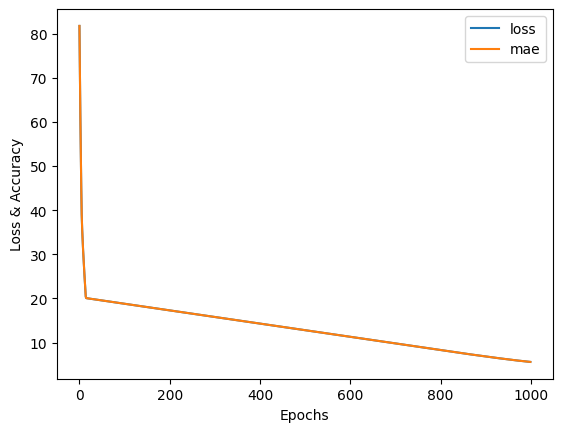

In [ ]:
pd.DataFrame(h.history).plot()
plt.xlabel("Epochs")
plt.ylabel("Loss & Accuracy")

In [ ]:
x_pred = model.predict(x_train)

15/15 [==============================] - 0s 2ms/step


In [ ]:
metrics.mean_absolute_error(y_train,x_pred)

5.600155713589536

In [ ]:
r2_score(y_train,x_pred)

-1.2986600160091508

In [ ]:
mean_squared_error(y_train,x_pred)

51.76925235223353

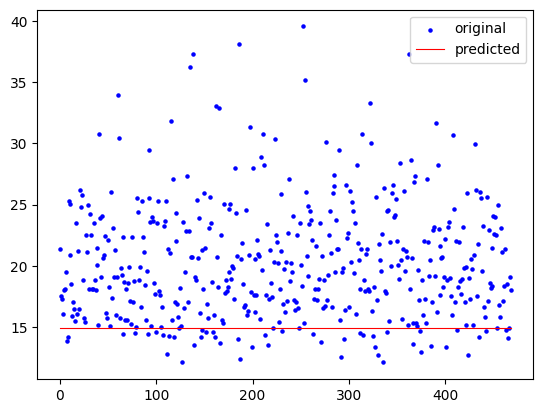

In [ ]:
x_ax = range(len(x_pred))
plt.scatter(x_ax, y_train, s=5, color="blue", label="original")
plt.plot(x_ax, x_pred, lw=0.8, color="red", label="predicted")
plt.legend()
plt.show()

In [ ]:
model.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_34 (Dense)            (None, 7)                 70        
                                                                 
 dense_35 (Dense)            (None, 5)                 40        
                                                                 
 dense_36 (Dense)            (None, 4)                 24        
                                                                 
 dense_37 (Dense)            (None, 3)                 15        
                                                                 
 dense_38 (Dense)            (None, 1)                 4         
                                                                 
Total params: 153 (612.00 Byte)
Trainable params: 153 (612.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


#### Testing dataset

In [ ]:
tf.random.set_seed(42)

# STEP1: Creating the model

model= tf.keras.Sequential([     tf.keras.layers.Dense(7, activation='relu'),
                            tf.keras.layers.Dense(5, activation='relu'),
                            tf.keras.layers.Dense(4, activation='relu'),
                            tf.keras.layers.Dense(3, activation='relu'),
                            tf.keras.layers.Dense(1, activation='linear')
])

# STEP2: Compiling the model

model.compile(loss= tf.keras.losses.mae,
              optimizer= tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics= ['mae'])

# STEP3: Fit the model

h= model.fit(x_train, y_train, epochs=500 ,verbose=0)

In [ ]:
model.evaluate(x_test, y_test)

7/7 [==============================] - 0s 5ms/step - loss: 4.0161 - mae: 4.0161


[4.016137599945068, 4.016137599945068]

Text(0, 0.5, 'Loss & Accuracy')

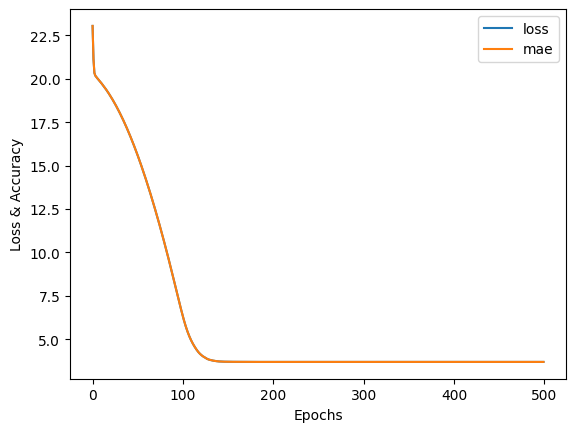

In [ ]:
pd.DataFrame(h.history).plot()
plt.xlabel("Epochs")
plt.ylabel("Loss & Accuracy")

In [ ]:
y_pred = model.predict(x_test)

7/7 [==============================] - 0s 3ms/step


In [ ]:
metrics.mean_absolute_error(y_test,y_pred)

4.016137213363677

In [ ]:
r2_score(y_test,y_pred)

-0.032627676427962715

In [ ]:
mean_squared_error(y_test,y_pred)

27.931555806172874

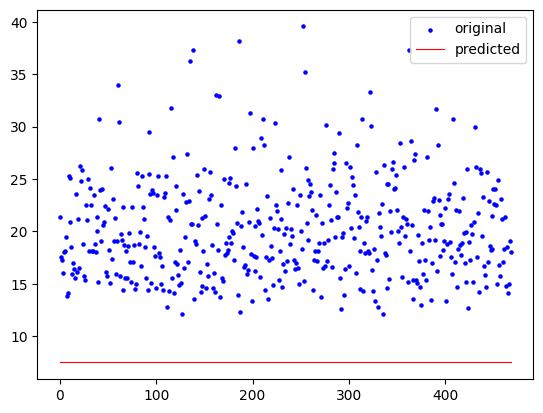

In [ ]:
x_ax = range(len(x_pred))
plt.scatter(x_ax, y_train, s=5, color="blue", label="original")
plt.plot(x_ax, x_pred, lw=0.8, color="red", label="predicted")
plt.legend()
plt.show()

In [ ]:
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_29 (Dense)            (None, 7)                 70        
                                                                 
 dense_30 (Dense)            (None, 5)                 40        
                                                                 
 dense_31 (Dense)            (None, 4)                 24        
                                                                 
 dense_32 (Dense)            (None, 3)                 15        
                                                                 
 dense_33 (Dense)            (None, 1)                 4         
                                                                 
Total params: 153 (612.00 Byte)
Trainable params: 153 (612.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## CNN

In [ ]:
x = data.drop(['S.No','Age','Class','Height','BMI'],axis=1).to_numpy()
y = data['BMI']

In [ ]:
x.shape

(671, 9)

In [ ]:
x = x.reshape(x.shape[0], x.shape[1], 1)
x.shape

(671, 9, 1)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state = 42)

In [ ]:
cnn_model = Sequential()
cnn_model.add(Conv1D(32, 2, activation="relu", input_shape=(9, 1)))
cnn_model.add(Flatten())
cnn_model.add(Dense(64, activation="relu"))
cnn_model.add(Dense(1))
cnn_model.compile(loss="mae", optimizer="Adam")

In [ ]:
cnn_model.summary

<bound method Model.summary of <keras.src.engine.sequential.Sequential object at 0x7af8e44c22c0>>

In [ ]:
cnn_model.fit(x_train, y_train, batch_size=12,epochs=400, verbose=0)

In [ ]:
print(cnn_model.evaluate(x_train, y_train))

15/15 [==============================] - 0s 2ms/step - loss: 0.5182
0.5181784629821777


#### Training dataset

In [ ]:
x_pred = cnn_model.predict(x_train)

15/15 [==============================] - 0s 2ms/step


In [ ]:
metrics.mean_absolute_error(y_train,x_pred)

MAE: 0.5374


In [ ]:
r2_score(y_train,x_pred)

0.9761371677865279

In [ ]:
mean_squared_error(y_train,x_pred)

0.5374265763942913

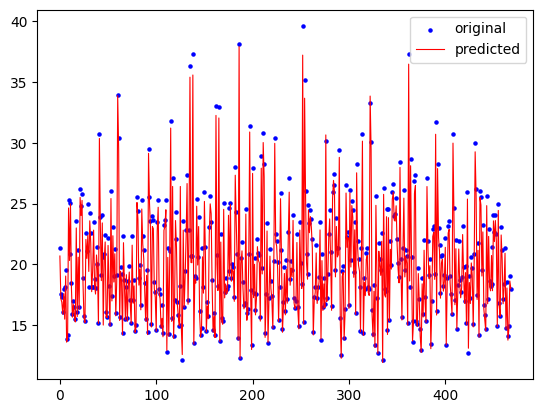

In [ ]:
x_ax = range(len(x_pred))
plt.scatter(x_ax, y_train, s=5, color="blue", label="original")
plt.plot(x_ax, x_pred, lw=0.8, color="red", label="predicted")
plt.legend()
plt.show()

#### Testing dataset

In [ ]:
y_pred = cnn_model.predict(x_test)

7/7 [==============================] - 0s 3ms/step


In [ ]:
metrics.mean_absolute_error(y_test,y_pred)

MAE: 0.7668


In [ ]:
r2_score(y_test,y_pred)

0.9716520701362398

In [ ]:
mean_squared_error(y_test,y_pred)

0.7667834235453308

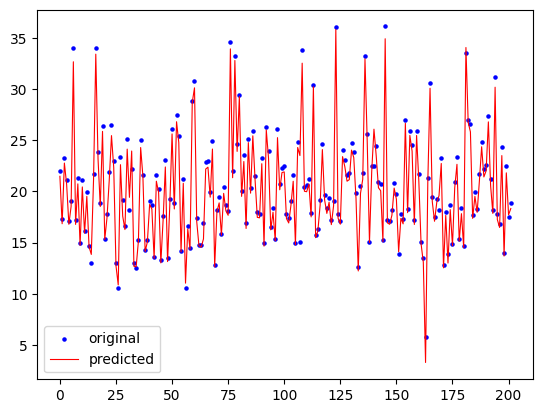

In [ ]:
x_ax = range(len(y_pred))
plt.scatter(x_ax, y_test, s=5, color="blue", label="original")
plt.plot(x_ax, y_pred, lw=0.8, color="red", label="predicted")
plt.legend()
plt.show()

## RNN

In [ ]:
rnn_model = Sequential()
rnn_model.add(SimpleRNN(32, input_shape=(9, 1)))
rnn_model.add(Dense(1, activation='linear'))

In [ ]:
rnn_model.compile(loss='mae', optimizer='Adam')

In [ ]:
rnn_model.fit(x_train, y_train, batch_size=12,epochs=100, verbose=0)

In [ ]:
print(rnn_model.evaluate(x_train, y_train))

15/15 [==============================] - 0s 4ms/step - loss: 0.7013
0.7013056874275208


#### Training dataset

In [ ]:
x_pred = rnn_model.predict(x_train)

15/15 [==============================] - 0s 3ms/step


In [ ]:
metrics.mean_absolute_error(y_train,x_pred)

0.7013056188843334

In [ ]:
r2_score(y_train,x_pred)

0.9408231121711602

In [ ]:
mean_squared_error(y_train,x_pred)

1.3327517849942137

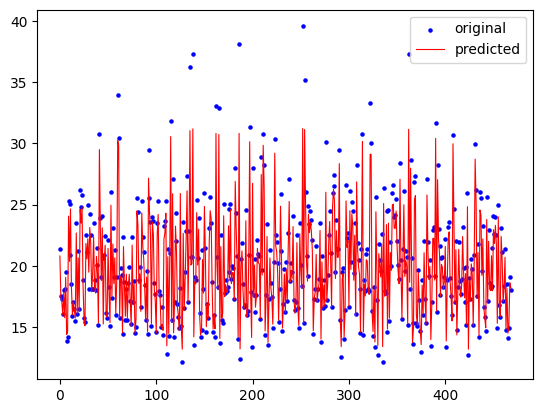

In [ ]:
x_ax = range(len(x_pred))
plt.scatter(x_ax, y_train, s=5, color="blue", label="original")
plt.plot(x_ax, x_pred, lw=0.8, color="red", label="predicted")
plt.legend()
plt.show()

#### Testing dataset

In [ ]:
y_pred = rnn_model.predict(x_test)

7/7 [==============================] - 0s 3ms/step


In [ ]:
print("MAE: %.4f" % metrics.mean_absolute_error(y_test, y_pred))

MAE: 0.8399


In [ ]:
r2_score(y_test,y_pred)

0.9308114202022849

In [ ]:
mean_squared_error(y_test,y_pred)

1.8714825506660147

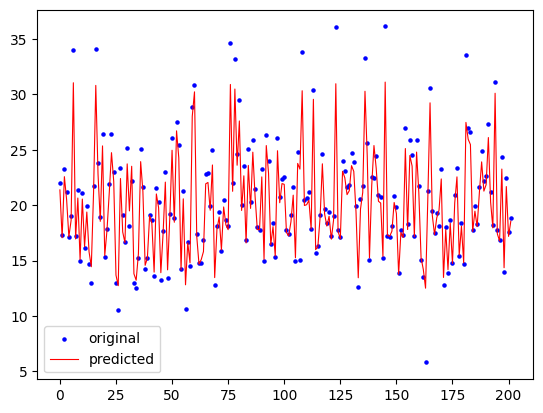

In [ ]:
x_ax = range(len(y_pred))
plt.scatter(x_ax, y_test, s=5, color="blue", label="original")
plt.plot(x_ax, y_pred, lw=0.8, color="red", label="predicted")
plt.legend()
plt.show()

# Forecating


#### model 0 forecasting

In [ ]:
df = data.drop(['S.No','Age','Class','Height'],axis=1)

In [ ]:
forecast_out = int(math.ceil(0.1 * len(df)))
forecast_out

68

In [ ]:
forecast_col = 'BMI'

In [ ]:
df['label'] = df[forecast_col].shift(-forecast_out)

In [ ]:
df

,gender,Weight,Hgt_Modified,BMI,veg_nonveg,Food_quantity,Skip_BF,Skip_lunch,Skip_dinner,Like_fruits,label
0,0,35.0,148.0,15.980000,0.0,3.0,1.0,0.0,0.0,1.0,23.92
1,0,26.0,128.0,15.950000,1.0,2.0,0.0,0.0,0.0,1.0,19.42
2,1,25.0,130.2,14.747488,1.0,3.0,0.0,0.0,0.0,1.0,18.10
3,1,45.0,139.6,23.090943,0.0,2.0,1.0,1.0,0.0,1.0,18.52
4,1,40.0,143.0,19.560859,0.0,3.0,0.0,0.0,0.0,1.0,25.04
...,...,...,...,...,...,...,...,...,...,...,...
666,1,41.0,134.0,22.833593,0.0,3.0,0.0,0.0,0.0,1.0,NaN
667,1,49.0,142.9,23.995600,1.0,3.0,2.0,0.0,0.0,1.0,NaN
668,1,33.5,127.1,20.737371,0.0,2.0,0.0,0.0,0.0,1.0,NaN
669,1,22.5,129.0,13.520822,0.0,3.0,0.0,0.0,0.0,1.0,NaN


In [ ]:
x = np.array(df.drop(['BMI','label'],axis=1))

In [ ]:
x

array([[  0. ,  35. , 148. , ...,   0. ,   0. ,   1. ],
       [  0. ,  26. , 128. , ...,   0. ,   0. ,   1. ],
       [  1. ,  25. , 130.2, ...,   0. ,   0. ,   1. ],
       ...,
       [  1. ,  33.5, 127.1, ...,   0. ,   0. ,   1. ],
       [  1. ,  22.5, 129. , ...,   0. ,   0. ,   1. ],
       [  1. ,  25.5, 132.4, ...,   0. ,   0. ,   1. ]])

In [ ]:
x = preprocessing.scale(x)

In [ ]:
x_lately = x[-forecast_out:]

In [ ]:
x = x[:-forecast_out]

In [ ]:
df.dropna(inplace=True)

In [ ]:
y = np.array(df['label'])

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state = 42)

In [ ]:
#ExtremeGradientBoosting
xgb =XGBRegressor(
    n_estimators=600,
    learning_rate=0.01,
    random_state=42)
xgb.fit(x_train, y_train)
y_pred = xgb.predict(x_test)

In [ ]:
forecast_set = xgb.predict(x_lately)
df['Forecast'] = np.nan

In [ ]:
last_no = df.iloc[-1].name
last_no

602

In [ ]:
last_unix = last_no

In [ ]:
next_no = 1
next_unix = last_unix + next_no

In [ ]:
for i in forecast_set:
    next = next_unix
    next_unix += 1
    df.loc[next] = [np.nan for _ in range(len(df.columns)-1)]+[i]

In [ ]:
df['Forecast'].unique()

array([        nan, 20.716362  , 26.03987694, 20.52575684, 22.83240128,
       21.56450653, 20.07204437, 18.55741692, 20.77916718, 22.19467545,
       20.63438988, 20.14435768, 26.10767746, 21.7352066 , 21.18081093,
       21.58472443, 24.56561279, 22.06686974, 22.70806885, 18.65398026,
       21.53255653, 19.14890671, 20.72221565, 20.72522926, 21.78468323,
       17.84656143, 22.05774879, 23.68733406, 23.14309883, 22.28696632,
       19.66152   , 18.93104744, 24.56163979, 21.76728249, 15.04654312,
       20.37216759, 18.73208618, 22.87626266, 20.48523903, 19.60397148,
       25.90148354, 20.78378868, 19.85910034, 20.62166977, 18.2327919 ,
       20.68914032, 18.3475914 , 21.65761757, 19.98092079, 20.61757851,
       17.73729515, 17.78090096, 18.85508537, 19.51549721, 19.72002411,
       16.77363205, 21.43345451, 19.29048538, 17.00317001, 22.27615356,
       20.33255768, 18.59291649, 20.64121628, 19.72570419, 17.61653709,
       20.94052315, 23.03745079, 19.1736908 , 20.14121246])

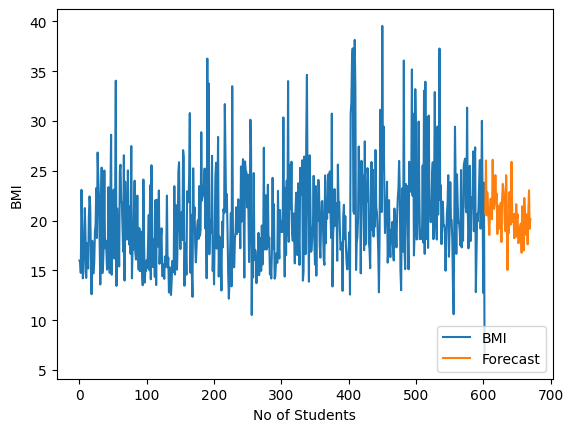

In [ ]:
df['BMI'].plot()
df['Forecast'].plot()
plt.legend(loc=4)
plt.xlabel('No of Students')
plt.ylabel('BMI')
plt.show()

# dividing data according to Class

In [ ]:
data

,S.No,Age,Class,gender,Weight,Height,Hgt_Modified,BMI,veg_nonveg,Food_quantity,Skip_BF,Skip_lunch,Skip_dinner,Like_fruits
0,1,10-11,5,0,35.0,1.48,148.0,15.980000,0.0,3.0,1.0,0.0,0.0,1.0
1,2,10-11,6,0,26.0,128.00,128.0,15.950000,1.0,2.0,0.0,0.0,0.0,1.0
2,3,11-12,6,1,25.0,130.20,130.2,14.747488,1.0,3.0,0.0,0.0,0.0,1.0
3,4,11-12,6,1,45.0,139.60,139.6,23.090943,0.0,2.0,1.0,1.0,0.0,1.0
4,5,11-12,6,1,40.0,143.00,143.0,19.560859,0.0,3.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
666,667,11-12,6,1,41.0,134.00,134.0,22.833593,0.0,3.0,0.0,0.0,0.0,1.0
667,668,11-12,6,1,49.0,142.90,142.9,23.995600,1.0,3.0,2.0,0.0,0.0,1.0
668,669,11-12,6,1,33.5,127.10,127.1,20.737371,0.0,2.0,0.0,0.0,0.0,1.0
669,670,11-12,6,1,22.5,129.00,129.0,13.520822,0.0,3.0,0.0,0.0,0.0,1.0


In [ ]:
data['Class'].unique()

array([5, 6, 7, 8, 9, 10, 'Inter 1st', 'B.Sc', 'Inter 2nd'], dtype=object)

### Middle class 5,6,7,8

In [ ]:
ms = data[data['Class'].isin([5, 6, 7, 8])].reset_index(drop=True)

In [ ]:
ms

,S.No,Age,Class,gender,Weight,Height,Hgt_Modified,BMI,veg_nonveg,Food_quantity,Skip_BF,Skip_lunch,Skip_dinner,Like_fruits
0,1,10-11,5,0,35.0,1.48,148.0,15.980000,0.0,3.0,1.0,0.0,0.0,1.0
1,2,10-11,6,0,26.0,128.00,128.0,15.950000,1.0,2.0,0.0,0.0,0.0,1.0
2,3,11-12,6,1,25.0,130.20,130.2,14.747488,1.0,3.0,0.0,0.0,0.0,1.0
3,4,11-12,6,1,45.0,139.60,139.6,23.090943,0.0,2.0,1.0,1.0,0.0,1.0
4,5,11-12,6,1,40.0,143.00,143.0,19.560859,0.0,3.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380,667,11-12,6,1,41.0,134.00,134.0,22.833593,0.0,3.0,0.0,0.0,0.0,1.0
381,668,11-12,6,1,49.0,142.90,142.9,23.995600,1.0,3.0,2.0,0.0,0.0,1.0
382,669,11-12,6,1,33.5,127.10,127.1,20.737371,0.0,2.0,0.0,0.0,0.0,1.0
383,670,11-12,6,1,22.5,129.00,129.0,13.520822,0.0,3.0,0.0,0.0,0.0,1.0


##### forecasting

In [ ]:
df = ms.drop(['S.No','Age','Class','Height'],axis=1)

In [ ]:
forecast_out = int(math.ceil(0.1 * len(df)))
forecast_out

39

In [ ]:
forecast_col = 'BMI'

In [ ]:
df['label'] = df[forecast_col].shift(-forecast_out)

In [ ]:
df

,gender,Weight,Hgt_Modified,BMI,veg_nonveg,Food_quantity,Skip_BF,Skip_lunch,Skip_dinner,Like_fruits,label
0,0,35.0,148.0,15.980000,0.0,3.0,1.0,0.0,0.0,1.0,18.01
1,0,26.0,128.0,15.950000,1.0,2.0,0.0,0.0,0.0,1.0,17.00
2,1,25.0,130.2,14.747488,1.0,3.0,0.0,0.0,0.0,1.0,15.08
3,1,45.0,139.6,23.090943,0.0,2.0,1.0,1.0,0.0,1.0,15.39
4,1,40.0,143.0,19.560859,0.0,3.0,0.0,0.0,0.0,1.0,23.36
...,...,...,...,...,...,...,...,...,...,...,...
380,1,41.0,134.0,22.833593,0.0,3.0,0.0,0.0,0.0,1.0,NaN
381,1,49.0,142.9,23.995600,1.0,3.0,2.0,0.0,0.0,1.0,NaN
382,1,33.5,127.1,20.737371,0.0,2.0,0.0,0.0,0.0,1.0,NaN
383,1,22.5,129.0,13.520822,0.0,3.0,0.0,0.0,0.0,1.0,NaN


In [ ]:
df.shape

(385, 11)

In [ ]:
x = np.array(df.drop(['BMI','label'],axis=1))

In [ ]:
x

array([[  0. ,  35. , 148. , ...,   0. ,   0. ,   1. ],
       [  0. ,  26. , 128. , ...,   0. ,   0. ,   1. ],
       [  1. ,  25. , 130.2, ...,   0. ,   0. ,   1. ],
       ...,
       [  1. ,  33.5, 127.1, ...,   0. ,   0. ,   1. ],
       [  1. ,  22.5, 129. , ...,   0. ,   0. ,   1. ],
       [  1. ,  25.5, 132.4, ...,   0. ,   0. ,   1. ]])

In [ ]:
x = preprocessing.scale(x)

In [ ]:
x_lately = x[-forecast_out:]

In [ ]:
x = x[:-forecast_out]

In [ ]:
df.dropna(inplace=True)

In [ ]:
y = np.array(df['label'])

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state = 42)

In [ ]:
#ExtremeGradientBoosting
xgb =XGBRegressor(
    n_estimators=350,
    learning_rate=0.01,
    random_state=42)
xgb.fit(x_train, y_train)
y_pred = xgb.predict(x_test)

In [ ]:
forecast_set = xgb.predict(x_lately)
df['Forecast'] = np.nan

In [ ]:
last_no = df.iloc[-1].name
last_no

345

In [ ]:
last_unix = last_no

In [ ]:
next_no = 1
next_unix = last_unix + next_no

In [ ]:
for i in forecast_set:
    next = next_unix
    next_unix += 1
    df.loc[next] = [np.nan for _ in range(len(df.columns)-1)]+[i]

In [ ]:
df['Forecast'].unique()

array([        nan, 20.62864685, 18.41409492, 20.50248146, 17.20756721,
       23.08117104, 21.01428032, 20.84000778, 21.73278236, 17.47376442,
       14.65076923, 18.84249878, 19.35109711, 18.97992325, 19.81785774,
       17.50474739, 20.14907455, 20.33494377, 20.21682739, 20.90452957,
       18.12171745, 21.4509449 , 20.99224472, 18.73033905, 19.97574234,
       20.11984634, 17.12853622, 17.4466114 , 18.18877983, 15.85969353,
       21.45215416, 19.31421471, 20.44476891, 19.1481266 , 22.98914528,
       20.40251923, 21.75399399, 20.03618813, 15.93191433])

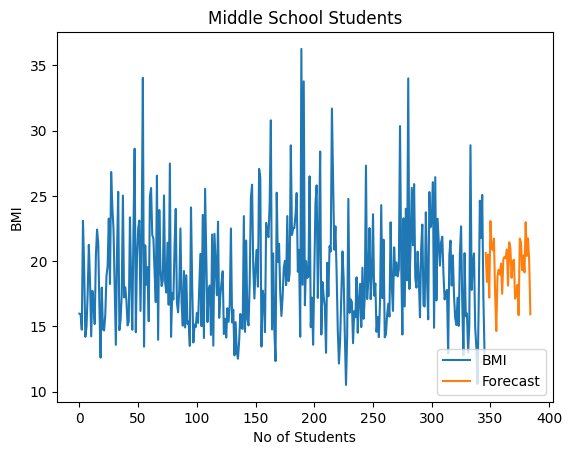

In [ ]:
df['BMI'].plot()
df['Forecast'].plot()
plt.legend(loc=4)
plt.title('Middle School Students')
plt.xlabel('No of Students')
plt.ylabel('BMI')
plt.show()

### High class 9,10, inter 1st yr, inter 2nd yr

In [ ]:
hs = data[data['Class'].isin([9, 10, 'Inter 1st', 'Inter 2nd'])].reset_index(drop=True)

In [ ]:
hs

,S.No,Age,Class,gender,Weight,Height,Hgt_Modified,BMI,veg_nonveg,Food_quantity,Skip_BF,Skip_lunch,Skip_dinner,Like_fruits
0,125,11-12,9,0,30.0,1.445,144.5,14.420000,0.0,3.0,1.0,0.0,1.0,1.0
1,227,13-14,9,1,29.0,147.000,147.0,13.400000,0.0,3.0,1.0,0.0,0.0,1.0
2,228,13-14,9,1,105.0,177.000,177.0,33.500000,0.0,1.0,0.0,0.0,0.0,1.0
3,229,13-14,10,0,40.0,1.445,144.5,19.230000,0.0,3.0,0.0,0.0,0.0,1.0
4,230,13-14,10,0,34.0,1.490,149.0,15.310000,0.0,2.0,2.0,2.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,589,17-18,10,0,54.0,140.500,140.5,27.355277,0.0,3.0,0.0,0.0,0.0,1.0
242,603,17-18,Inter 1st,0,15.0,1.607,160.7,5.810000,1.0,3.0,2.0,0.0,0.0,1.0
243,604,17-18,Inter 2nd,1,54.0,1.725,172.5,18.140000,0.0,3.0,2.0,0.0,0.0,1.0
244,605,17-18,Inter 2nd,1,90.0,164.500,164.5,33.250000,0.0,3.0,0.0,0.0,0.0,1.0


##### forecasting

In [ ]:
df = hs.drop(['S.No','Age','Class','Height'],axis=1)

In [ ]:
forecast_out = int(math.ceil(0.1 * len(df)))
forecast_out

25

In [ ]:
forecast_col = 'BMI'

In [ ]:
df['label'] = df[forecast_col].shift(-forecast_out)

In [ ]:
df

,gender,Weight,Hgt_Modified,BMI,veg_nonveg,Food_quantity,Skip_BF,Skip_lunch,Skip_dinner,Like_fruits,label
0,0,30.0,144.5,14.420000,0.0,3.0,1.0,0.0,1.0,1.0,15.84
1,1,29.0,147.0,13.400000,0.0,3.0,1.0,0.0,0.0,1.0,20.28
2,1,105.0,177.0,33.500000,0.0,1.0,0.0,0.0,0.0,1.0,30.13
3,0,40.0,144.5,19.230000,0.0,3.0,0.0,0.0,0.0,1.0,27.36
4,0,34.0,149.0,15.310000,0.0,2.0,2.0,2.0,2.0,1.0,19.21
...,...,...,...,...,...,...,...,...,...,...,...
241,0,54.0,140.5,27.355277,0.0,3.0,0.0,0.0,0.0,1.0,NaN
242,0,15.0,160.7,5.810000,1.0,3.0,2.0,0.0,0.0,1.0,NaN
243,1,54.0,172.5,18.140000,0.0,3.0,2.0,0.0,0.0,1.0,NaN
244,1,90.0,164.5,33.250000,0.0,3.0,0.0,0.0,0.0,1.0,NaN


In [ ]:
x = np.array(df.drop(['BMI','label'],axis=1))

In [ ]:
x

array([[  0. ,  30. , 144.5, ...,   0. ,   1. ,   1. ],
       [  1. ,  29. , 147. , ...,   0. ,   0. ,   1. ],
       [  1. , 105. , 177. , ...,   0. ,   0. ,   1. ],
       ...,
       [  1. ,  54. , 172.5, ...,   0. ,   0. ,   1. ],
       [  1. ,  90. , 164.5, ...,   0. ,   0. ,   1. ],
       [  0. ,  69. , 165. , ...,   0. ,   0. ,   1. ]])

In [ ]:
x = preprocessing.scale(x)

In [ ]:
x_lately = x[-forecast_out:]

In [ ]:
x = x[:-forecast_out]

In [ ]:
df.dropna(inplace=True)

In [ ]:
y = np.array(df['label'])

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state = 42)

In [ ]:
#ExtremeGradientBoosting
xgb =XGBRegressor(
    n_estimators=600,
    learning_rate=0.01,
    random_state=42)
xgb.fit(x_train, y_train)
y_pred = xgb.predict(x_test)

In [ ]:
forecast_set = xgb.predict(x_lately)
df['Forecast'] = np.nan

In [ ]:
last_no = df.iloc[-1].name
last_no

220

In [ ]:
last_unix = last_no

In [ ]:
next_no = 1
next_unix = last_unix + next_no

In [ ]:
for i in forecast_set:
    next = next_unix
    next_unix += 1
    df.loc[next] = [np.nan for _ in range(len(df.columns)-1)]+[i]

In [ ]:
df['Forecast'].unique()

array([        nan, 17.6279068 , 22.06186104, 20.05123138, 26.17398453,
       21.85159683, 19.88841629, 20.56474495, 31.19336891, 22.63983536,
       22.80425835, 22.60086441, 20.44927979, 21.21093369, 22.36066055,
       18.26585007, 23.69573212, 20.41392517, 21.24473953, 17.65815353,
       21.3567543 , 22.81449127, 18.94021797, 23.09715652, 23.01277542,
       20.24001312])

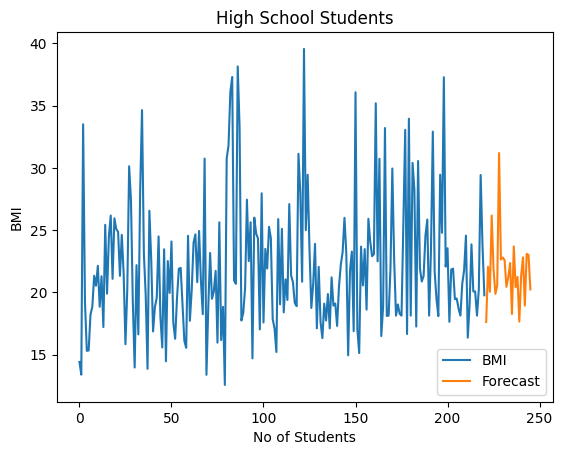

In [ ]:
df['BMI'].plot()
df['Forecast'].plot()
plt.legend(loc=4)
plt.title('High School Students')
plt.xlabel('No of Students')
plt.ylabel('BMI')
plt.show()

### Degree

In [ ]:
degree = data[data['Class'].isin(['B.Sc'])].reset_index(drop=True)

In [ ]:
degree

,S.No,Age,Class,gender,Weight,Height,Hgt_Modified,BMI,veg_nonveg,Food_quantity,Skip_BF,Skip_lunch,Skip_dinner,Like_fruits
0,571,16-17,B.Sc,1,46.0,1.600,160.0,17.968750,0.0,3.0,1.0,0.0,1.0,1.0
1,572,16-17,B.Sc,0,55.0,1.470,147.0,25.452358,0.0,3.0,0.0,0.0,0.0,1.0
2,591,17-18,B.Sc,0,47.0,169.000,169.0,16.456006,0.0,1.0,2.0,0.0,0.0,1.0
3,592,17-18,B.Sc,0,51.0,157.000,157.0,20.690495,0.0,3.0,0.0,0.0,0.0,1.0
4,593,17-18,B.Sc,0,53.0,163.000,163.0,19.948060,0.0,3.0,0.0,0.0,1.0,1.0
5,594,17-18,B.Sc,0,54.0,1.590,159.0,21.359915,0.0,3.0,1.0,0.0,1.0,1.0
6,595,17-18,B.Sc,0,64.0,1.630,163.0,24.088223,0.0,3.0,1.0,0.0,0.0,1.0
7,596,17-18,B.Sc,0,68.0,1.615,161.5,26.071370,0.0,3.0,0.0,0.0,0.0,1.0
8,597,17-18,B.Sc,0,51.0,1.630,163.0,19.195303,1.0,3.0,0.0,0.0,1.0,1.0
9,598,17-18,B.Sc,0,55.0,1.610,161.0,21.218317,0.0,3.0,2.0,0.0,0.0,1.0


In [ ]:
degree.shape

(40, 14)

##### forecasting

In [ ]:
df = degree.drop(['S.No','Age','Class','Height'],axis=1)

In [ ]:
forecast_out = int(math.ceil(0.2 * len(df)))
forecast_out

8

In [ ]:
forecast_col = 'BMI'

In [ ]:
df['label'] = df[forecast_col].shift(-forecast_out)

In [ ]:
df

,gender,Weight,Hgt_Modified,BMI,veg_nonveg,Food_quantity,Skip_BF,Skip_lunch,Skip_dinner,Like_fruits,label
0,1,46.0,160.0,17.968750,0.0,3.0,1.0,0.0,1.0,1.0,19.195303
1,0,55.0,147.0,25.452358,0.0,3.0,0.0,0.0,0.0,1.0,21.218317
2,0,47.0,169.0,16.456006,0.0,1.0,2.0,0.0,0.0,1.0,30.021502
3,0,51.0,157.0,20.690495,0.0,3.0,0.0,0.0,0.0,1.0,22.313278
4,0,53.0,163.0,19.948060,0.0,3.0,0.0,0.0,1.0,1.0,23.805402
5,0,54.0,159.0,21.359915,0.0,3.0,1.0,0.0,1.0,1.0,18.610229
6,0,64.0,163.0,24.088223,0.0,3.0,1.0,0.0,0.0,1.0,21.357796
7,0,68.0,161.5,26.071370,0.0,3.0,0.0,0.0,0.0,1.0,21.295295
8,0,51.0,163.0,19.195303,1.0,3.0,0.0,0.0,1.0,1.0,26.122449
9,0,55.0,161.0,21.218317,0.0,3.0,2.0,0.0,0.0,1.0,17.804967


In [ ]:
x = np.array(df.drop(['BMI','label'],axis=1))

In [ ]:
x

array([[  1. ,  46. , 160. ,   0. ,   3. ,   1. ,   0. ,   1. ,   1. ],
       [  0. ,  55. , 147. ,   0. ,   3. ,   0. ,   0. ,   0. ,   1. ],
       [  0. ,  47. , 169. ,   0. ,   1. ,   2. ,   0. ,   0. ,   1. ],
       [  0. ,  51. , 157. ,   0. ,   3. ,   0. ,   0. ,   0. ,   1. ],
       [  0. ,  53. , 163. ,   0. ,   3. ,   0. ,   0. ,   1. ,   1. ],
       [  0. ,  54. , 159. ,   0. ,   3. ,   1. ,   0. ,   1. ,   1. ],
       [  0. ,  64. , 163. ,   0. ,   3. ,   1. ,   0. ,   0. ,   1. ],
       [  0. ,  68. , 161.5,   0. ,   3. ,   0. ,   0. ,   0. ,   1. ],
       [  0. ,  51. , 163. ,   1. ,   3. ,   0. ,   0. ,   1. ,   1. ],
       [  0. ,  55. , 161. ,   0. ,   3. ,   2. ,   0. ,   0. ,   1. ],
       [  0. ,  74. , 157. ,   1. ,   3. ,   0. ,   0. ,   0. ,   1. ],
       [  0. ,  55. , 157. ,   0. ,   3. ,   1. ,   0. ,   1. ,   1. ],
       [  0. ,  55. , 152. ,   0. ,   3. ,   1. ,   1. ,   1. ,   1. ],
       [  0. ,  45. , 155.5,   1. ,   2. ,   0. ,   0. ,   0. , 

In [ ]:
x = preprocessing.scale(x)

In [ ]:
x_lately = x[-forecast_out:]

In [ ]:
x = x[:-forecast_out]

In [ ]:
df.dropna(inplace=True)

In [ ]:
y = np.array(df['label'])

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state = 42)

In [ ]:
#ExtremeGradientBoosting
xgb =XGBRegressor(
    n_estimators=600,
    learning_rate=0.01,
    random_state=42)
xgb.fit(x_train, y_train)
y_pred = xgb.predict(x_test)

In [ ]:
forecast_set = xgb.predict(x_lately)
df['Forecast'] = np.nan

In [ ]:
last_no = df.iloc[-1].name
last_no

31

In [ ]:
last_unix = last_no

In [ ]:
next_no = 1
next_unix = last_unix + next_no

In [ ]:
for i in forecast_set:
    next = next_unix
    next_unix += 1
    df.loc[next] = [np.nan for _ in range(len(df.columns)-1)]+[i]

In [ ]:
df['Forecast'].unique()

array([        nan, 22.33081055, 18.20979309, 29.67261887, 25.54758835,
       21.56301689, 26.54943466, 22.29924011, 21.56256294])

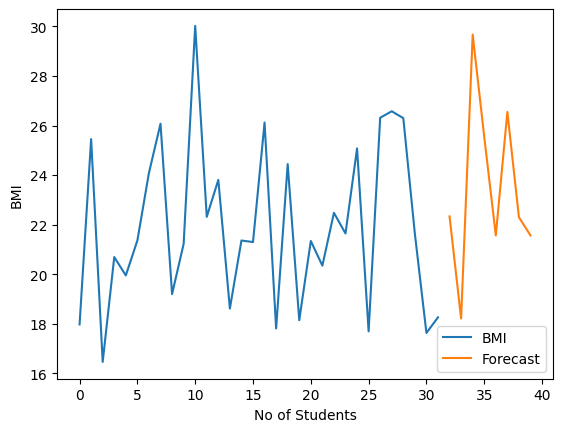

In [ ]:
df['BMI'].plot()
df['Forecast'].plot()
plt.legend(loc=4)
plt.xlabel('No of Students')
plt.ylabel('BMI')
plt.show()

### Male data

In [ ]:
male = data[data['gender'].isin([1])].reset_index(drop=True)

In [ ]:
male

,S.No,Age,Class,gender,Weight,Height,Hgt_Modified,BMI,veg_nonveg,Food_quantity,Skip_BF,Skip_lunch,Skip_dinner,Like_fruits
0,3,11-12,6,1,25.0,130.2,130.2,14.747488,1.0,3.0,0.0,0.0,0.0,1.0
1,4,11-12,6,1,45.0,139.6,139.6,23.090943,0.0,2.0,1.0,1.0,0.0,1.0
2,5,11-12,6,1,40.0,143.0,143.0,19.560859,0.0,3.0,0.0,0.0,0.0,1.0
3,6,11-12,6,1,26.0,135.3,135.3,14.202924,0.0,3.0,0.0,0.0,0.0,1.0
4,7,11-12,6,1,34.0,150.9,150.9,14.931397,0.0,3.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,667,11-12,6,1,41.0,134.0,134.0,22.833593,0.0,3.0,0.0,0.0,0.0,1.0
199,668,11-12,6,1,49.0,142.9,142.9,23.995600,1.0,3.0,2.0,0.0,0.0,1.0
200,669,11-12,6,1,33.5,127.1,127.1,20.737371,0.0,2.0,0.0,0.0,0.0,1.0
201,670,11-12,6,1,22.5,129.0,129.0,13.520822,0.0,3.0,0.0,0.0,0.0,1.0


In [ ]:
male.shape

(203, 14)

##### forecasting

In [ ]:
df = male.drop(['S.No','Age','Class','Height','gender'],axis=1)

In [ ]:
forecast_out = int(math.ceil(0.2 * len(df)))
forecast_out

41

In [ ]:
forecast_col = 'BMI'

In [ ]:
df['label'] = df[forecast_col].shift(-forecast_out)

In [ ]:
df

,Weight,Hgt_Modified,BMI,veg_nonveg,Food_quantity,Skip_BF,Skip_lunch,Skip_dinner,Like_fruits,label
0,25.0,130.2,14.747488,1.0,3.0,0.0,0.0,0.0,1.0,17.400000
1,45.0,139.6,23.090943,0.0,2.0,1.0,1.0,0.0,1.0,13.869519
2,40.0,143.0,19.560859,0.0,3.0,0.0,0.0,0.0,1.0,15.958651
3,26.0,135.3,14.202924,0.0,3.0,0.0,0.0,0.0,1.0,18.048818
4,34.0,150.9,14.931397,0.0,3.0,0.0,0.0,0.0,1.0,27.074999
...,...,...,...,...,...,...,...,...,...,...
198,41.0,134.0,22.833593,0.0,3.0,0.0,0.0,0.0,1.0,NaN
199,49.0,142.9,23.995600,1.0,3.0,2.0,0.0,0.0,1.0,NaN
200,33.5,127.1,20.737371,0.0,2.0,0.0,0.0,0.0,1.0,NaN
201,22.5,129.0,13.520822,0.0,3.0,0.0,0.0,0.0,1.0,NaN


In [ ]:
x = np.array(df.drop(['BMI','label'],axis=1))

In [ ]:
x

array([[ 25. , 130.2,   1. , ...,   0. ,   0. ,   1. ],
       [ 45. , 139.6,   0. , ...,   1. ,   0. ,   1. ],
       [ 40. , 143. ,   0. , ...,   0. ,   0. ,   1. ],
       ...,
       [ 33.5, 127.1,   0. , ...,   0. ,   0. ,   1. ],
       [ 22.5, 129. ,   0. , ...,   0. ,   0. ,   1. ],
       [ 25.5, 132.4,   0. , ...,   0. ,   0. ,   1. ]])

In [ ]:
x = preprocessing.scale(x)

In [ ]:
x_lately = x[-forecast_out:]

In [ ]:
x = x[:-forecast_out]

In [ ]:
df.dropna(inplace=True)

In [ ]:
y = np.array(df['label'])

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state = 42)

In [ ]:
#ExtremeGradientBoosting
xgb =XGBRegressor(
    n_estimators=600,
    learning_rate=0.01,
    random_state=42)
xgb.fit(x_train, y_train)
y_pred = xgb.predict(x_test)

In [ ]:
forecast_set = xgb.predict(x_lately)
df['Forecast'] = np.nan

In [ ]:
last_no = df.iloc[-1].name
last_no

161

In [ ]:
last_unix = last_no

In [ ]:
next_no = 1
next_unix = last_unix + next_no

In [ ]:
for i in forecast_set:
    next = next_unix
    next_unix += 1
    df.loc[next] = [np.nan for _ in range(len(df.columns)-1)]+[i]

In [ ]:
df['Forecast'].unique()

array([        nan, 23.17815399, 19.06360054, 18.17009926, 16.27641678,
       15.88055515, 19.76486588, 19.0703125 , 19.51372528, 19.08547592,
       19.57784462, 21.64389992, 19.65514565, 19.52711105, 19.17013168,
       17.76104164, 19.4245739 , 18.00200844, 17.36539268, 23.28106308,
       20.87978172, 14.6235466 , 21.91571236, 23.0526123 , 23.11891747,
       23.48843384, 14.63422871, 21.79986572, 26.22199059, 22.21494102,
       20.59402275, 23.60055733, 32.31407547, 18.28723717, 15.93247986,
       23.06098557, 19.78509712, 17.77196884, 17.95346451])

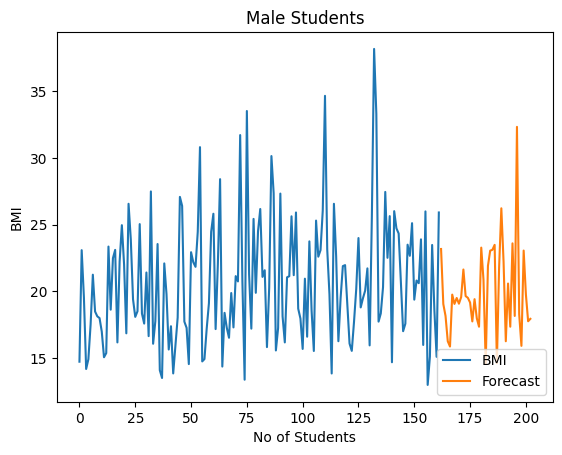

In [ ]:
df['BMI'].plot()
df['Forecast'].plot()
plt.legend(loc=4)
plt.title('Male Students')
plt.xlabel('No of Students')
plt.ylabel('BMI')
plt.show()

### Female dataset

In [ ]:
female = data[data['gender'].isin([0])].reset_index(drop=True)

In [ ]:
female

,S.No,Age,Class,gender,Weight,Height,Hgt_Modified,BMI,veg_nonveg,Food_quantity,Skip_BF,Skip_lunch,Skip_dinner,Like_fruits
0,1,10-11,5,0,35.0,1.480,148.0,15.980000,0.0,3.0,1.0,0.0,0.0,1.0
1,2,10-11,6,0,26.0,128.000,128.0,15.950000,1.0,2.0,0.0,0.0,0.0,1.0
2,11,11-12,6,0,27.0,137.700,137.7,14.239537,1.0,3.0,0.0,0.0,0.0,1.0
3,12,11-12,6,0,35.0,140.500,140.5,17.730272,0.0,3.0,0.0,0.0,0.0,1.0
4,13,10-11,6,0,26.0,129.000,129.0,16.660000,0.0,2.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
463,644,10-11,7,0,49.0,1.464,146.4,22.860000,0.0,3.0,1.0,0.0,0.0,1.0
464,645,10-11,7,0,37.0,1.435,143.5,17.960000,0.0,3.0,0.0,0.0,0.0,1.0
465,646,10-11,7,0,48.0,1.428,142.8,23.530000,0.0,3.0,0.0,0.0,0.0,1.0
466,650,10-11,6,0,34.0,142.000,142.0,16.910000,0.0,3.0,0.0,0.0,0.0,1.0


In [ ]:
female.shape

(468, 14)

##### forecasting

In [ ]:
df = female.drop(['S.No','Age','Class','Height','gender'],axis=1)

In [ ]:
forecast_out = int(math.ceil(0.2 * len(df)))
forecast_out

94

In [ ]:
forecast_col = 'BMI'

In [ ]:
df['label'] = df[forecast_col].shift(-forecast_out)

In [ ]:
df

,Weight,Hgt_Modified,BMI,veg_nonveg,Food_quantity,Skip_BF,Skip_lunch,Skip_dinner,Like_fruits,label
0,35.0,148.0,15.980000,0.0,3.0,1.0,0.0,0.0,1.0,12.531150
1,26.0,128.0,15.950000,1.0,2.0,0.0,0.0,0.0,1.0,14.878000
2,27.0,137.7,14.239537,1.0,3.0,0.0,0.0,0.0,1.0,14.814815
3,35.0,140.5,17.730272,0.0,3.0,0.0,0.0,0.0,1.0,23.456558
4,26.0,129.0,16.660000,0.0,2.0,0.0,0.0,0.0,1.0,14.588506
...,...,...,...,...,...,...,...,...,...,...
463,49.0,146.4,22.860000,0.0,3.0,1.0,0.0,0.0,1.0,NaN
464,37.0,143.5,17.960000,0.0,3.0,0.0,0.0,0.0,1.0,NaN
465,48.0,142.8,23.530000,0.0,3.0,0.0,0.0,0.0,1.0,NaN
466,34.0,142.0,16.910000,0.0,3.0,0.0,0.0,0.0,1.0,NaN


In [ ]:
x = np.array(df.drop(['BMI','label'],axis=1))

In [ ]:
x

array([[ 35. , 148. ,   0. , ...,   0. ,   0. ,   1. ],
       [ 26. , 128. ,   1. , ...,   0. ,   0. ,   1. ],
       [ 27. , 137.7,   1. , ...,   0. ,   0. ,   1. ],
       ...,
       [ 48. , 142.8,   0. , ...,   0. ,   0. ,   1. ],
       [ 34. , 142. ,   0. , ...,   0. ,   0. ,   1. ],
       [ 23. , 138. ,   0. , ...,   0. ,   0. ,   1. ]])

In [ ]:
x = preprocessing.scale(x)

In [ ]:
x_lately = x[-forecast_out:]

In [ ]:
x = x[:-forecast_out]

In [ ]:
df.dropna(inplace=True)

In [ ]:
y = np.array(df['label'])

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state = 42)

In [ ]:
#ExtremeGradientBoosting
xgb =XGBRegressor(
    n_estimators=600,
    learning_rate=0.01,
    random_state=42)
xgb.fit(x_train, y_train)
y_pred = xgb.predict(x_test)

In [ ]:
forecast_set = xgb.predict(x_lately)
df['Forecast'] = np.nan

In [ ]:
last_no = df.iloc[-1].name
last_no

373

In [ ]:
last_unix = last_no

In [ ]:
next_no = 1
next_unix = last_unix + next_no

In [ ]:
for i in forecast_set:
    next = next_unix
    next_unix += 1
    df.loc[next] = [np.nan for _ in range(len(df.columns)-1)]+[i]

In [ ]:
df['Forecast'].unique()

array([        nan, 18.02141953, 20.20147705, 20.74999809, 17.29652214,
       20.28093719, 21.49973106, 23.23304749, 22.37110901, 19.18648911,
       22.68787575, 16.62909508, 20.10043907, 19.06911659, 20.92577744,
       22.25997734, 27.43527222, 19.47572136, 22.6708374 , 20.59594154,
       21.35307121, 23.25744629, 23.33471298, 22.27870941, 16.9194088 ,
       17.89219093, 19.28725433, 22.41772652, 16.86710167, 18.12705612,
       20.72582054, 19.43882561, 21.78292847, 22.59773254, 19.25221634,
       28.21891022, 19.02236366, 21.65006638, 24.85726547, 21.95724106,
       27.9824276 , 19.4635067 , 21.89797974, 23.75152588, 22.12990189,
       22.08903694, 16.93081856, 21.84711075, 24.01292801, 21.55594254,
       23.32428932, 22.96536446, 21.59140205, 21.01861382, 21.2454586 ,
       19.68494034, 18.09223175, 21.21650124, 19.3366642 , 19.83000565,
       21.02947235, 20.07303619, 18.16950035, 21.28136063, 24.46284294,
       21.74850464, 25.87431335, 22.74465179, 18.63250732, 18.24

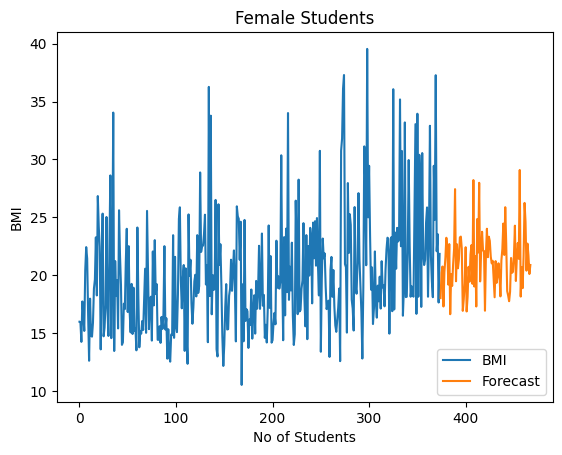

In [ ]:
df['BMI'].plot()
df['Forecast'].plot()
plt.legend(loc=4)
plt.title('Female Students')
plt.xlabel('No of Students')
plt.ylabel('BMI')
plt.show()

# dividing data according to Age

In [ ]:
new_df = data[(data['Age'] == '11-12') | (data['Age'] == '12-13')]

In [ ]:
new_df

In [ ]:
def persistence(last_ob, n_seq):
	return [last_ob for i in range(n_seq)]

In [ ]:
def make_forecasts(train, test, n_lag, n_seq):
	forecasts = list()
	for i in range(len(test)):
		X, y = test[i, 0:n_lag], test[i, n_lag:]
		# make forecast
		forecast = persistence(X[-1], n_seq)
		# store the forecast
		forecasts.append(forecast)
	return forecasts

In [ ]:
forecasts = make_forecasts(train, test, 1, 3)
forecasts

# BMI plot

In [ ]:
data = pd.DataFrame({'BMI': [15.98,15.95,14.74748762,23.09094342,19.56085872,14.20292373,14.93139682,17.53007284,21.25572491,18.5,
       14.2395375 , 17.73027191, 16.66      , 15.18461293, 20.44444444,
       22.42603962, 21.43298116, 16.51833393, 12.60853035, 17.97361147,
       14.77      , 14.69204722, 15.89279357, 18.84      , 19.6248999 ,
       23.26866949, 18.25064127, 26.8364381 , 24.18963411, 22.46      ,
       18.14      , 13.59      , 20.63      , 25.32      , 14.72      ,
       15.46      , 17.42      , 25.03      , 17.23      , 18.01      ,
       17.        , 15.08      , 15.39      , 23.36      , 18.64      ,
       14.75      , 22.33      , 28.62      , 14.56      , 20.3       ,
       22.49      , 23.11      , 16.19      , 22.24      , 34.05      ,
       13.45      , 21.22      , 18.2       , 19.55      , 15.4       ,
       24.96      , 25.61      , 22.01      , 21.73      , 19.15      ,
       16.87      , 26.56      , 13.98      , 23.92      , 19.42      ,
       18.1       , 18.52      , 25.04      , 18.35      , 17.6       ,
       21.42      , 27.48456066, 14.2       , 17.54      , 17.07      ,
       21.12      , 24.01      , 16.82      , 16.09      , 17.78      ,
       22.51      , 16.81      , 15.06      , 19.25      , 14.92      ,
       18.92      , 15.2       , 15.38      , 13.51      , 24.12      ,
       13.77      , 15.15      , 14.95      , 16.04      , 15.27      ,
       20.56      , 15.02      , 23.55      , 14.11      , 25.55482243,
       20.41966068, 15.34      , 17.8       , 14.35      , 22.05      ,
       13.53      , 22.1       , 19.8       , 17.39      , 23.03      ,
       15.66      , 17.4       , 18.37      , 19.23      , 14.42      ,
       15.59277702, 14.15266618, 16.39436938, 15.36351166, 16.65972511,
       22.50930904, 15.30612245, 16.27809284, 12.78704246, 15.33      ,
       13.02083333, 12.53114988, 13.86951939, 15.95865065, 14.8780004 ,
       14.81481481, 23.45655845, 14.58850594, 21.58429543, 15.54327637,
       18.36900337, 24.86723105, 25.86559831, 19.56295525, 17.13934422,
       19.67627396, 20.87750274, 18.04881825, 27.07499908, 26.40235457,
       13.46      , 17.74622893, 17.27831131, 14.56815817, 22.93787225,
       22.18934911, 21.8435624 , 24.46021385, 30.7976462 , 14.768431  ,
       20.59362316, 14.67      , 12.34418817, 25.25221867, 19.95379122,
       21.33333333, 17.5852654 , 15.80440847, 17.23957181, 19.47714681,
       20.03517805, 18.16724663, 23.46      , 18.46763659, 19.06292126,
       28.8772665 , 22.01180256, 22.52648208, 22.55176871, 23.55593268,
       25.22728777, 19.19622886, 20.87623707, 14.21      , 36.26862055,
       18.1979502 , 33.78226206, 16.62187509, 20.01517673, 18.72243911,
       18.84410274, 26.50417957, 14.94432559, 17.20900453, 13.6       ,
       19.11372667, 24.45435097, 25.81498476, 17.1875    , 22.03172568,
       28.40236686, 14.38432684, 18.40133206, 17.2879069 , 16.5384848 ,
       12.98      , 19.8838008 , 17.31235023, 21.15004165, 20.75032284,
       31.70008459, 26.12798232, 20.88282966, 22.67573696, 19.11      ,
       14.7       , 12.16      , 17.24      , 20.75      , 13.4       ,
       33.5       , 15.31      , 18.229     , 18.85      , 21.34      ,
       18.65      , 20.54      , 22.14      , 21.3       , 17.22      ,
       25.43      , 19.9       , 24.51      , 26.17      , 21.09      ,
       14.28      , 25.95      , 25.08      , 24.87      , 21.33      ,
       24.62      , 21.59      , 15.84      , 20.28      , 30.13      ,
       27.36      , 10.52      , 19.21      , 14.29023467, 24.77365884,
       16.04471818, 17.06555671, 16.88019391, 13.71742112, 16.17122473,
       15.70395512, 18.76524676, 14.52      , 17.10175544, 18.26150475,
       14.95151437, 19.5046224 , 15.58791228, 17.26420745, 27.32299318,
       17.10451296, 18.61149584, 22.541561  , 17.09      , 18.86773911,
       23.60127725, 17.36044134, 18.29611559, 14.58679141, 15.71530485,
       14.18437201, 17.0066073 , 24.29802788, 17.17452267, 21.65      ,
       14.17082935, 14.38830436, 15.86986709, 16.74361342, 15.75869498,
       22.98190175, 15.73      , 21.06      , 18.91      , 19.91      ,
       19.39      , 30.36      , 19.94      , 14.38      , 23.29      ,
       16.53      , 24.02      , 18.53483202, 34.00999043, 17.87      ,
       21.14182974, 25.62384024, 21.21831719, 25.91068435, 18.71326547,
       17.97536915, 20.73132657, 18.68224572, 15.7017634 , 20.95717116,
       22.81      , 16.6167879 , 16.53035482, 23.74844507, 18.55677322,
       15.54863613, 25.30363219, 22.60306517, 23.09524031, 26.05674041,
       13.97107166, 14.9       , 26.44      , 16.63353483, 28.25698989,
       34.63561966, 23.15250643, 19.78961357, 13.86595363, 26.56031915,
       22.62230182, 16.86625063, 18.83333993, 24.49754514, 18.01405515,
       15.58104015, 23.46455423, 14.4711742 , 22.51829612, 19.96247056,
       24.09040989, 23.26      , 17.5663492 , 16.27908546, 19.52374087,
       21.89767805, 21.97133586, 19.04432133, 16.10451184, 15.55555556,
       24.54796673, 17.72471947, 21.46      , 20.19509221, 23.99716264,
       24.66437478, 20.82291337, 24.93769664, 20.96245906, 18.25310979,
       30.743977  , 13.38488995, 18.80896391, 19.66      , 23.16774337,
       19.49165079, 20.06920415, 21.72812896, 15.9674844 , 25.62639052,
       21.45726808, 21.87871581, 19.02497027, 17.07048854, 17.53      ,
       17.7999288 , 12.93928886, 20.45184304, 21.58003378, 18.13121943,
       17.31298609, 15.65978009, 15.1068195 , 16.17204177, 17.2       ,
       18.84515944, 12.57482018, 30.757401  , 31.80614886, 36.1141058 ,
       37.29562   , 20.9566075 , 20.69049454, 38.14474058, 33.28319983,
       15.04      , 18.359375  , 20.32388137, 27.44657818, 22.51824274,
       25.63691716, 14.70537943, 26.00832503, 24.72518293, 24.33747972,
       20.61      , 17.02969058, 27.96      , 17.59      , 23.5       ,
       21.91871465, 25.26985372, 24.35591021, 17.86317246, 17.11634611,
       15.21997622, 22.67      , 25.88757396, 25.11      , 18.4       ,
       21.05      , 27.09      , 21.37      , 20.82      , 16.83      ,
       12.8       , 18.9       , 31.13      , 27.98      , 20.86      ,
       39.55      , 25.        , 29.45      , 23.41      , 18.75      ,
       20.675     , 20.62      , 23.9       , 15.78      , 22.0541903 ,
       17.61300615, 16.33169676, 19.10009183, 17.74584488, 19.87216354,
       16.        , 21.21      , 18.94      , 17.31      , 20.44      ,
       22.22      , 23.24      , 25.99      , 23.14      , 13.01      ,
       21.75      , 23.28      , 16.89      , 36.07      , 17.04      ,
       15.131     , 23.68      , 23.48      , 18.62      , 15.11      ,
       25.91      , 24.09      , 22.91      , 23.07      , 35.185     ,
       22.5       , 30.73      , 16.5       , 33.2       , 28.89      ,
       18.11      , 21.96      , 29.95      , 22.58      , 19.04      ,
       18.28      , 25.54      , 33.05      , 33.95      , 30.4       ,
       28.21      , 17.26      , 30.55      , 21.94      , 20.88      ,
       19.84      , 21.322     , 24.566     , 25.855     , 23.404     ,
       32.91      , 21.68      , 19.47      , 20.6       , 24.79      ,
       37.28      , 22.07      , 17.64      , 21.84      , 21.91      ,
       19.46      , 19.51      , 18.7       , 14.97      , 20.703     ,
       21.77      , 24.56      , 16.37      , 19.066     , 23.86      ,
       20.08      , 10.6       , 20.26      , 29.43      , 23.77      ,
       24.64      , 21.78435665, 19.77237654, 19.81784449, 17.51463112,
       19.81      , 17.96875   , 25.45235781, 26.22      , 20.83      ,
       31.34      , 17.21      , 19.1       , 25.51      , 17.94      ,
       20.25      , 22.37      , 21.311     , 26.95      , 18.93      ,
       27.35527666, 12.82      , 16.45600644, 19.94805977, 21.35991456,
       24.08822312, 26.07137038, 19.1953028 , 30.02150189, 22.31327843,
       12.73      , 23.80540166,  5.81      , 33.25      , 25.34      ,
       18.61022942, 21.3577956 , 21.29529475, 26.12244898, 17.80496713,
       24.44444444, 21.33821064, 20.34279778, 22.47658689, 21.64127424,
       25.07619305, 17.68978885, 26.31463532, 26.57537949, 15.3       ,
       26.29848784, 21.63114885, 17.62538055, 18.25631871, 30.70040788,
       22.93975069, 22.32142857, 26.98600101, 24.00548697, 16.21      ,
       23.01      , 26.03      , 18.3       , 12.75      , 13.92      ,
       23.52      , 21.25      , 21.16      , 14.99      , 22.86      ,
       17.96      , 23.53      , 14.66      , 20.76241452, 24.32531988,
       16.91      , 20.43734905, 23.34226175, 18.84546717, 15.27212826,
       20.88799855, 15.52227904, 24.65303141, 15.25033701, 30.41854536,
       12.1       , 23.6231393 , 13.28427688, 15.7324976 , 19.71120941,
       22.83359323, 23.99560048, 20.73737141, 13.52082207, 14.54669088]})

In [ ]:
weight_ranges = [(float('-inf'), 18.5), (18.5, 24.9), (25, 29.9), (30, float('inf'))]
categories = ['Underweight', 'Healthy weight', 'Overweight', 'Obese']

In [ ]:
data['category'] = pd.cut(data['BMI'], bins=[range[0] for range in weight_ranges] + [weight_ranges[-1][1]], labels=categories)

In [ ]:
category_counts = data['category'].value_counts()

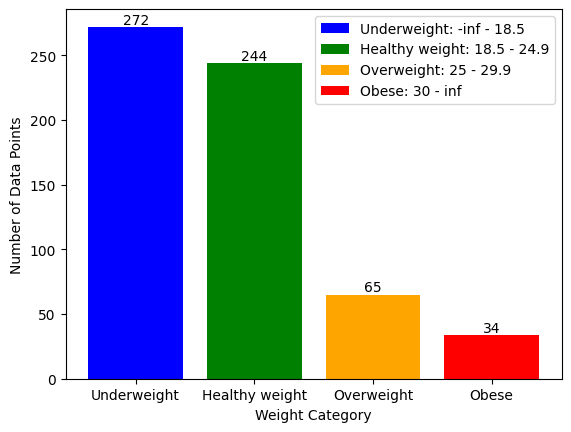

In [ ]:
colors = ['blue', 'green', 'orange', 'red']
bars = plt.bar(categories, category_counts, color=colors)

for bar, count in zip(bars, category_counts):
    plt.text(bar.get_x() + bar.get_width() / 2, count, str(count), ha='center', va='bottom')

legend_labels = [f'{category}: {range[0]} - {range[1]}' for category, range in zip(categories, weight_ranges)]
legend_colors = colors[:len(categories)]

plt.legend(handles=bars, labels=legend_labels, loc='upper right')

plt.xlabel('Weight Category')
plt.ylabel('Number of Data Points')

plt.show()